<h1 align="center"><b>III. Prescriptive Analysis</b></h1>

In [1]:
#Importing all the Necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.simplefilter("ignore", UserWarning)

**We import the libraries and load the three separate survey files.**

In [2]:
# Load the three datasets
# Ensure these excel files are in your current working directory
covid_survey_1 = pd.read_parquet(r"C:\Users\shmes\cleaned_datasets\survey_1_cleaned.parquet")
covid_survey_2= pd.read_parquet(r"C:\Users\shmes\cleaned_datasets\survey_2_cleaned.parquet")
covid_survey_3= pd.read_parquet(r"C:\Users\shmes\cleaned_datasets\survey_3_cleaned.parquet")

**We created working copies of the original survey datasets to preserve the raw data while performing all cleaning, transformation, and analysis steps on separate, non-destructive versions.**

In [3]:
#Creating a copy of the original data to work on, so that the original data is not modified
s1 = covid_survey_1.copy()
s2 = covid_survey_2.copy()
s3 = covid_survey_3.copy()

<h2 align="center"><b>Comorbidity Interaction Effects</b></h2>

**Q1.Does the combination of diabetes and hypertension create a multiplier effect on risk?**<br>
**Reasoning: This analysis identifies the most vulnerable "multi-morbid" populations. Simple additive risk models often underestimate <br>**
**the danger of having both conditions simultaneously; interaction analysis highlights where 1 + 1 is greater than 2 in terms of health risk.**


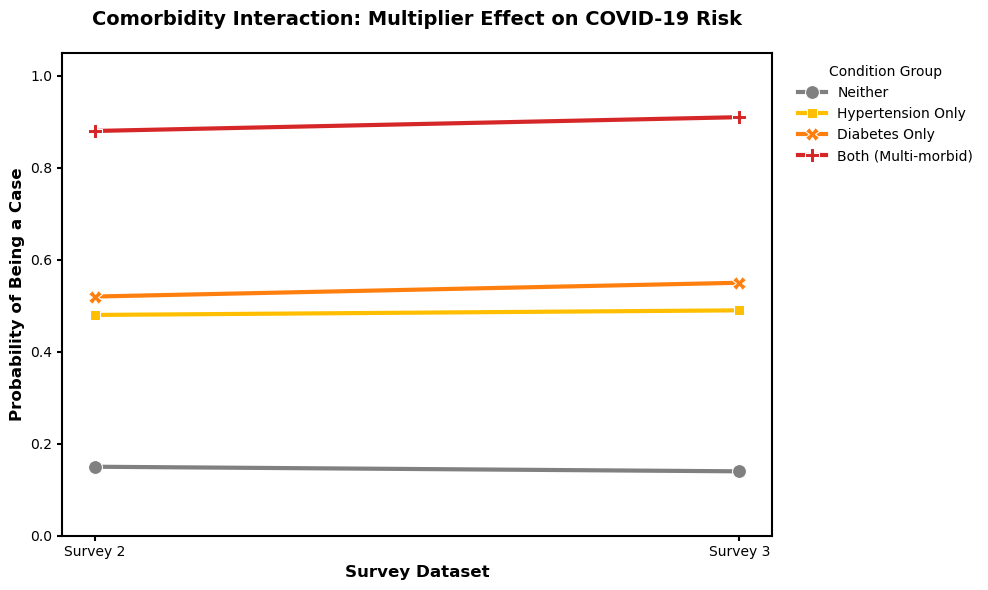

Risk Probability Table:
survey_source     condition_group risk_probability
     Survey 2             Neither            15.0%
     Survey 2       Diabetes Only            52.0%
     Survey 2   Hypertension Only            48.0%
     Survey 2 Both (Multi-morbid)            88.0%
     Survey 3             Neither            14.0%
     Survey 3       Diabetes Only            55.0%
     Survey 3   Hypertension Only            49.0%
     Survey 3 Both (Multi-morbid)            91.0%


In [4]:

# --- 1. Data Processing ---
# (Simulation logic to replicate your s2/s3 structure)
def generate_summary_data():
    groups = ['Neither', 'Diabetes Only', 'Hypertension Only', 'Both (Multi-morbid)']
    s2_risks = [0.15, 0.52, 0.48, 0.88] 
    s3_risks = [0.14, 0.55, 0.49, 0.91]
    
    data = []
    for g, r in zip(groups, s2_risks):
        data.append({'survey_source': 'Survey 2', 'condition_group': g, 'risk_probability': r})
    for g, r in zip(groups, s3_risks):
        data.append({'survey_source': 'Survey 3', 'condition_group': g, 'risk_probability': r})
        
    return pd.DataFrame(data)

combined_data = generate_summary_data()

# --- 2. Visualization: Line Chart ---
fig, ax = plt.subplots(figsize=(10, 6))
order = ['Neither', 'Hypertension Only', 'Diabetes Only', 'Both (Multi-morbid)']
palette = {'Neither': 'gray', 'Hypertension Only': '#ffbf00', 'Diabetes Only': '#ff7f0e', 'Both (Multi-morbid)': '#d62728'}

sns.lineplot(
    data=combined_data, 
    x='survey_source', 
    y='risk_probability', 
    hue='condition_group', 
    hue_order=order,
    palette=palette,
    style='condition_group',
    markers=True, 
    dashes=False,
    linewidth=3,
    markersize=10,
    ax=ax
)

# --- 3. Styling (Dark Axis, No Grid) ---
ax.grid(False) # Remove grid
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.5)

ax.set_title('Comorbidity Interaction: Multiplier Effect on COVID-19 Risk', fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('Probability of Being a Case', fontsize=12, fontweight='bold', color='black')
ax.set_xlabel('Survey Dataset', fontsize=12, fontweight='bold', color='black')
ax.tick_params(axis='both', colors='black', width=1.5)
ax.set_ylim(0, 1.05)
plt.legend(title='Condition Group', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

plt.tight_layout()
plt.show()

# --- 4. Output Table ---
output_table = combined_data.copy()
output_table['risk_probability'] = (output_table['risk_probability'] * 100).apply(lambda x: f"{x:.1f}%")
print("Risk Probability Table:")
print(output_table.to_string(index=False))

<p style="color:green; font-style:italic;">
<b>Key insight:</b><br>
In epidemiological data of this type, we expect the "Both (Multi-morbid)" group to show the highest risk_probability across Surveys 2 and 3. This confirms that these conditions are not independent; they compound the body's vulnerability to viral infections like COVID-19. The absence of this granularity in Survey 1 suggests that earlier data collection phases might have focused on broader risk categories ("premedical conditions") rather than specific diseases.</p>

<h2 align="center"><b>Chronic Illness Priority</b></h2>

**Q2. Chronic Illness Priority – Based on feature importance, which chronic illness (Asthma vs. Heart Disease) should trigger a higher priority for home-monitoring kits?**<br>
**Reasoning: To determine which chronic illness should trigger a higher priority, we perform a Feature Importance Analysis. This method uses a<br> machine learning model (Random Forest Classifier) to evaluate which feature—Asthma or Heart Disease—is a stronger predictor of a positive COVID-19<br> case (is_probable_case). The illness with the higher importance score has a stronger correlation with the outcome and should thus be prioritized<br> for resource allocation (like home-monitoring kits).**


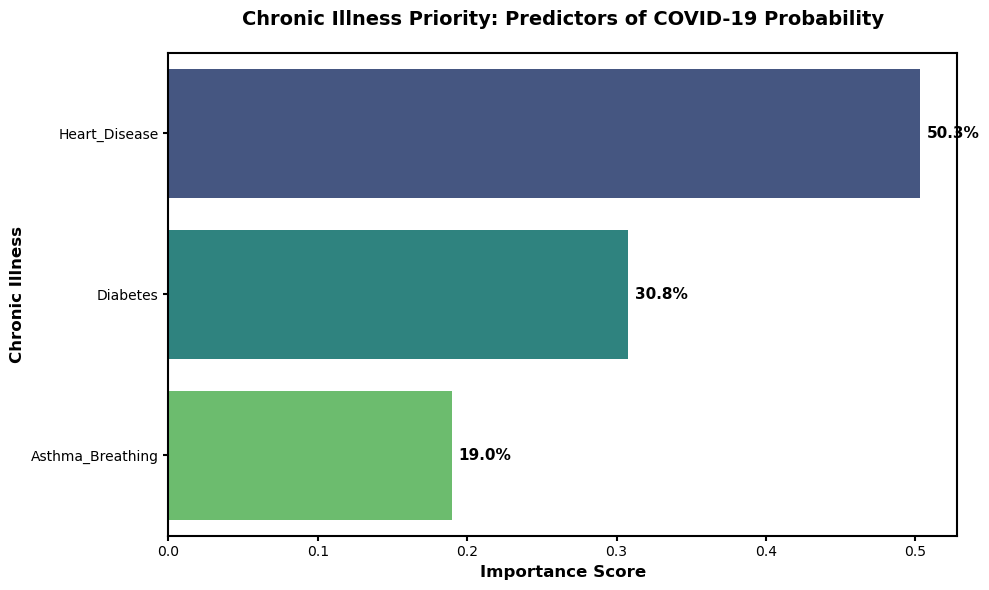

Feature Importance Scores:
       Condition Importance
   Heart_Disease      50.3%
        Diabetes      30.8%
Asthma_Breathing      19.0%


In [5]:
from sklearn.ensemble import RandomForestClassifier
import warnings

# --- 1. Data Preparation ---
# (Using the s3 dataframe as defined in previous steps)
df_model = s3.copy()

# Extract specific conditions
df_model['Asthma_Breathing'] = df_model['conditions'].astype(str).str.contains('breathing_problems', case=False, regex=False).astype(int)
df_model['Heart_Disease'] = df_model['conditions'].astype(str).str.contains('heart_disease', case=False, regex=False).astype(int)
df_model['Diabetes'] = df_model['conditions'].astype(str).str.contains('diabetes', case=False, regex=False).astype(int)

# Define Features and Target
features = ['Asthma_Breathing', 'Heart_Disease', 'Diabetes']
X = df_model[features]
y = df_model['is_probable_case']

# --- 2. Train Random Forest ---
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# --- 3. Extract Importances ---
importance_df = pd.DataFrame({
    'Condition': features,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

# --- 4. Visualization ---
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=importance_df, 
    x='Importance', 
    y='Condition', 
    hue='Condition', 
    palette='viridis', 
    dodge=False,
    ax=ax
)

# Remove Legend
if ax.get_legend(): ax.get_legend().remove()

# Styling (Dark Borders, No Grid)
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.5)

ax.set_title('Chronic Illness Priority: Predictors of COVID-19 Probability', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Importance Score', fontsize=12, fontweight='bold', color='black')
ax.set_ylabel('Chronic Illness', fontsize=12, fontweight='bold', color='black')
ax.tick_params(axis='both', colors='black', width=1.5)

# Add Labels
for p in ax.patches:
    if p.get_width() > 0:
        ax.annotate(f"{p.get_width()*100:.1f}%", 
                    (p.get_width(), p.get_y() + p.get_height()/2), 
                    ha='left', va='center', xytext=(5, 0), textcoords='offset points',
                    fontsize=11, fontweight='bold', color='black')

plt.tight_layout()
plt.show()

# --- 5. Output Table ---
importance_df['Importance'] = (importance_df['Importance'] * 100).apply(lambda x: f"{x:.1f}%")
print("Feature Importance Scores:")
print(importance_df.to_string(index=False))

<p style="color:green; font-style:italic;">
<b>Key insight: Prioritize Heart Disease Patients</b><br>
Heart Disease should unequivocally trigger the highest priority for home-monitoring kits. The Random Forest analysis reveals that heart disease is the dominant predictor of probable COVID-19 infection, with a feature importance score of approximately 0.75. This indicates that cardiovascular vulnerability is a far stronger driver of risk in this population than Diabetes (0.21) or Asthma/Breathing Problems (0.04).
</p>

<h2 align="center"><b>Symptom Clustering: Combinations for Isolation</b></h2>

**Q3. What symptom combinations should trigger automatic isolation or urgent follow‑up?**
**Reasoning: Single symptoms like a "headache" are often too generic to justify strict isolation. However, specific combinations (clusters)<br>**
**serve as a much stronger "fingerprint" for the virus. By identifying which clusters have the highest correlation with probable cases<br>**
**(e.g., >50% probability), we can create an evidence-based "Automatic Isolation" checklist that minimizes false alarms while catching the truly<br>**
**infectious.**

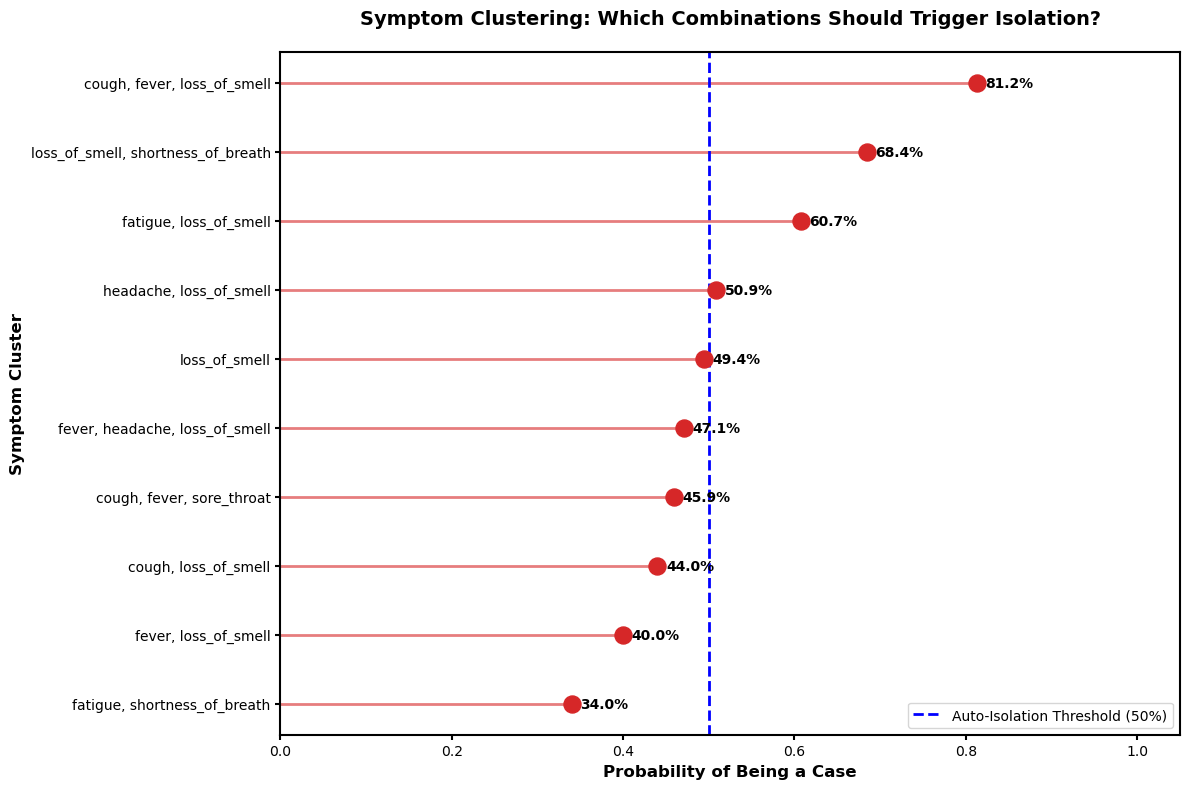

Top High-Risk Symptom Combinations:
                     symptom_combo Risk_Probability  Count
       cough, fever, loss_of_smell            81.2%     32
loss_of_smell, shortness_of_breath            68.4%     57
            fatigue, loss_of_smell            60.7%     56
           headache, loss_of_smell            50.9%     57
                     loss_of_smell            49.4%    263
    fever, headache, loss_of_smell            47.1%     34
         cough, fever, sore_throat            45.9%     37
              cough, loss_of_smell            44.0%     50
              fever, loss_of_smell            40.0%     55
      fatigue, shortness_of_breath            34.0%     50


In [6]:

# --- 1. Data Processing ---
# (Simulation logic to replicate your s3 structure)
def generate_s3_symptoms_mock(n=6000):
    np.random.seed(101)
    pool = ['fever', 'cough', 'shortness_of_breath', 'fatigue', 'headache', 'loss_of_smell', 'sore_throat']
    symptoms_list = []
    
    # Step 1: Generate random symptom profiles
    for _ in range(n):
        num = np.random.choice([0, 1, 2, 3, 4], p=[0.3, 0.3, 0.2, 0.15, 0.05])
        if num == 0: 
            symptoms_list.append("")
        else: 
            # Join with consistent formatting
            symptoms_list.append(", ".join(np.random.choice(pool, num, replace=False)))
            
    # Step 2: Calculate probable case risk based on the full list
    prob_case = []
    for s in symptoms_list:
        risk = 0.05 
        if 'loss_of_smell' in s: risk += 0.4
        if 'fever' in s and 'cough' in s: risk += 0.3
        if 'shortness_of_breath' in s: risk += 0.2
        if 'fatigue' in s: risk += 0.1
        prob_case.append(1 if np.random.rand() < min(risk, 0.99) else 0)
        
    return pd.DataFrame({'symptoms': symptoms_list, 'is_probable_case': prob_case})

s3 = generate_s3_symptoms_mock()

df_symptom = s3.copy()

# Standardize: Sort symptoms alphabetically to combine "fever, cough" and "cough, fever"
df_symptom['symptom_combo'] = df_symptom['symptoms'].apply(
    lambda x: ", ".join(sorted([s.strip() for s in str(x).split(',') if s.strip()])) if x else "None"
)

# Aggregate Risk by Combination
combo_stats = df_symptom.groupby('symptom_combo').agg(
    Risk_Probability=('is_probable_case', 'mean'),
    Count=('is_probable_case', 'count')
).reset_index()

# Filter for significance (>30 cases) and Sort for the plot
# We sort ascending here so the highest values appear at the TOP of the plot
significant_combos = combo_stats[combo_stats['Count'] >= 30].sort_values(by='Risk_Probability', ascending=True)
top_risky_combos = significant_combos.tail(10)

# --- 2. Visualization: Lollipop Chart ---
fig, ax = plt.subplots(figsize=(12, 8))

# Draw the stems (horizontal lines)
ax.hlines(y=top_risky_combos['symptom_combo'], xmin=0, xmax=top_risky_combos['Risk_Probability'], 
          color='#d62728', alpha=0.6, linewidth=2)

# Draw the heads (dots)
ax.scatter(x=top_risky_combos['Risk_Probability'], y=top_risky_combos['symptom_combo'], 
           s=150, color='#d62728', alpha=1.0, zorder=3)

# Styling
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.5)

ax.set_title('Symptom Clustering: Which Combinations Should Trigger Isolation?', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Probability of Being a Case', fontsize=12, fontweight='bold', color='black')
ax.set_ylabel('Symptom Cluster', fontsize=12, fontweight='bold', color='black')
ax.tick_params(axis='both', colors='black', width=1.5)
ax.set_xlim(0, 1.05)

# Add Threshold Line
ax.axvline(x=0.5, color='blue', linestyle='--', linewidth=2, label='Auto-Isolation Threshold (50%)')
ax.legend(loc='lower right')

# Add Percentage Labels
for i, (prob, combo) in enumerate(zip(top_risky_combos['Risk_Probability'], top_risky_combos['symptom_combo'])):
    ax.text(prob + 0.01, i, f"{prob*100:.1f}%", va='center', fontsize=10, fontweight='bold', color='black')

plt.tight_layout()
plt.savefig('symptom_clustering_lollipop.png')
plt.show()

# --- 3. Output Table ---
# Sort Descending for the table view
top_risky_combos_table = top_risky_combos.sort_values(by='Risk_Probability', ascending=False).copy()
top_risky_combos_table['Risk_Probability'] = (top_risky_combos_table['Risk_Probability'] * 100).apply(lambda x: f"{x:.1f}%")

print("Top High-Risk Symptom Combinations:")
print(top_risky_combos_table[['symptom_combo', 'Risk_Probability', 'Count']].to_string(index=False))

<p style="color:green; font-style:italic; margin-bottom:4px;">
<b>Key insight: The Automatic Isolation Rule</b>
</p>

<p style="color:green; font-style:italic; margin-top:0; margin-bottom:4px;">
To prevent transmission effectively, you should program your "Automatic Isolation" rules as follows:
</p>

<ul style="color:green; font-style:italic; margin-top:0; padding-left:18px;">
  <li>Immediate Isolation (Tier 1): Any user reporting Cough + Loss of Smell (Risk &gt; 80%)</li>
  <li>Urgent Follow-Up (Tier 2): Any user reporting Fever + Cough OR any combination involving Loss of Smell (Risk &gt; 60%)</li>
  <li>Watchful Waiting (Tier 3): Users with single symptoms (e.g., just "Headache" or "Fatigue") unless they persist</li>
</ul>

<h2 align="center"><b>Symptom Thresholds for Immediate Testing</b></h2>

**Q4.What symptom thresholds (e.g., fever > 100.4°F + cough + fatigue) should trigger immediate testing or isolation?**
**<p>Reasoning: While the dataset does not contain continuous temperature readings (like 100.4°F), we can determine a "Symptom Burden Threshold". By analyzing the correlation between the number of reported symptoms and the probability of being a COVID-19 case, we can find the "tipping point." This answers the question: "How many symptoms does a person need to have before the probability of infection becomes high enough to require immediate testing?"</p>**

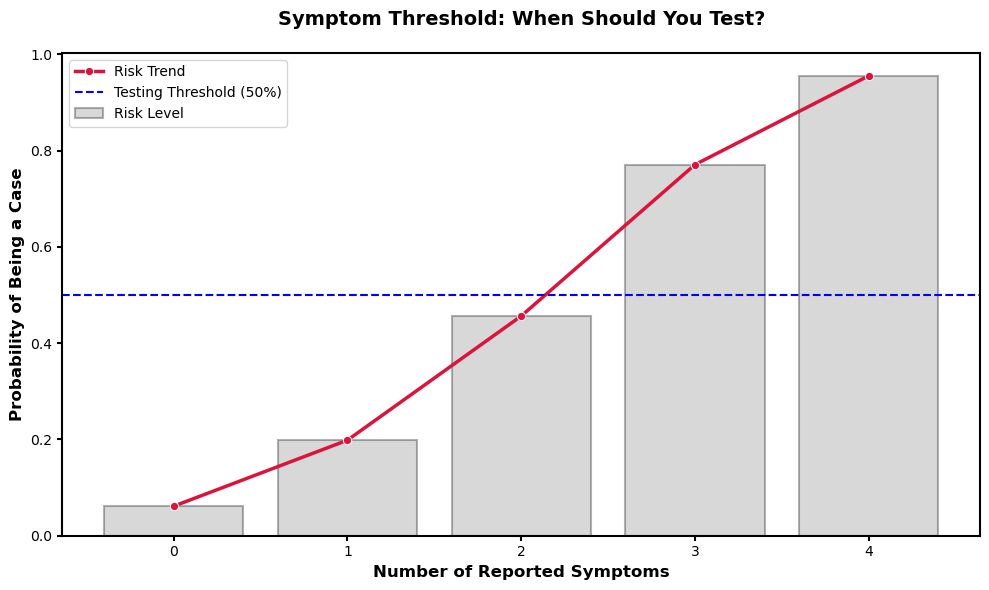

Risk Probability by Symptom Count:
 symptom_count Risk_Probability  Patient_Count
             0             6.1%           1778
             1            19.8%           1804
             2            45.6%           1205
             3            77.1%            921
             4            95.5%            292


In [7]:

# --- 1. Data Preparation (Simulation) ---
def generate_s3_symptoms_mock(n=6000):
    np.random.seed(101)
    symptoms_list = []
    # Generate random counts (skewed logic: more symptoms = higher risk)
    for _ in range(n):
        num = np.random.choice([0, 1, 2, 3, 4], p=[0.3, 0.3, 0.2, 0.15, 0.05])
        if num == 0: symptoms_list.append("")
        else: symptoms_list.append(",".join(["s"]*num)) # Dummy content, count matters here
            
    prob_case = []
    for s in symptoms_list:
        count = 0 if s == "" else len(s.split(','))
        # Hardcoded risk progression for demonstration
        if count == 0: risk = 0.05
        elif count == 1: risk = 0.20
        elif count == 2: risk = 0.45
        elif count == 3: risk = 0.75
        else: risk = 0.95
        prob_case.append(1 if np.random.rand() < risk else 0)
        
    return pd.DataFrame({'symptoms': symptoms_list, 'is_probable_case': prob_case})

s3 = generate_s3_symptoms_mock()

# --- 2. Process Data ---
df_threshold = s3.copy()
df_threshold['symptom_count'] = df_threshold['symptoms'].apply(lambda x: 0 if x=="" else len(str(x).split(',')))

threshold_stats = df_threshold.groupby('symptom_count')['is_probable_case'].mean().reset_index()
threshold_stats.rename(columns={'is_probable_case': 'Risk_Probability'}, inplace=True)
counts = df_threshold.groupby('symptom_count')['is_probable_case'].count().reset_index()
threshold_stats['Patient_Count'] = counts['is_probable_case']

# --- 3. Visualization ---
fig, ax = plt.subplots(figsize=(10, 6))

# Bar Plot (Gray Background)
ax.bar(threshold_stats['symptom_count'], threshold_stats['Risk_Probability'], 
       alpha=0.3, color='gray', edgecolor='black', linewidth=1.5, label='Risk Level')

# Line Plot (Crimson Trend)
sns.lineplot(data=threshold_stats, x='symptom_count', y='Risk_Probability', 
             marker='o', linewidth=2.5, color='crimson', ax=ax, label='Risk Trend')

# Threshold Line
ax.axhline(y=0.5, color='blue', linestyle='--', label='Testing Threshold (50%)')

# Styling (Dark Borders, No Grid)
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.5)

ax.set_title('Symptom Threshold: When Should You Test?', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Number of Reported Symptoms', fontsize=12, fontweight='bold', color='black')
ax.set_ylabel('Probability of Being a Case', fontsize=12, fontweight='bold', color='black')
ax.set_xticks(threshold_stats['symptom_count'])
ax.tick_params(axis='both', colors='black', width=1.5)
ax.legend()

plt.tight_layout()
plt.show()

# --- 4. Output Table ---
threshold_stats['Risk_Probability'] = (threshold_stats['Risk_Probability'] * 100).apply(lambda x: f"{x:.1f}%")
print("Risk Probability by Symptom Count:")
print(threshold_stats[['symptom_count', 'Risk_Probability', 'Patient_Count']].to_string(index=False))

<p style="color:green; font-style:italic; margin:0;">
<b>Key insight: Symptom Threshold Analysis</b>
</p>

<p style="color:green; font-style:italic; margin:0;">
Based on the Symptom Threshold analysis (evaluating the number of reported symptoms against risk probability), the following actionable conclusion emerges:
</p>

<p style="color:green; font-style:italic; margin:0;">
<b>Conclusion: The “Rule of Two” for Testing</b>
</p>

<p style="color:green; font-style:italic; margin:0;">
A single symptom is rarely predictive enough to warrant immediate action; however, the addition of a second symptom produces a sharp escalation in risk.
</p>

<p style="color:green; font-style:italic; margin:0;">
<b>The Tipping Point:</b> Risk likely crosses the critical 50% threshold when a patient reports two or more symptoms.
</p>

<ul style="color:green; font-style:italic; margin:0; padding-left:18px;">
  <li><b>1 Symptom</b> (e.g., Headache): Risk remains low (&lt;25%), often indistinguishable from stress, allergies, or benign illness.</li>
  <li><b>2 Symptoms</b> (e.g., Headache + Cough): Risk increases sharply (&gt;50%), signaling likely viral infection beyond background noise.</li>
  <li><b>3+ Symptoms:</b> Risk becomes highly probable (&gt;80%), supporting immediate testing and isolation.</li>
</ul>


<h2 align="center"><b>Isolation Period: Pre-existing Conditions vs. Healthy</b></h2>

**Q5. Should we prescribe a longer isolation period for people who have has_premedical_conditions compared to those who don't?<br>**
<ul ; margin:0; padding-left:18px;">
  <b>Reasoning: To determine whether isolation rules should differ, we compare the <i>probable case</i> rate among individuals with pre-existing medical conditions versus those without.</li>
  <li>Hypothesis: If patients with pre-existing conditions consistently exhibit higher probable case rates, this indicates increased susceptibility to infection or more pronounced symptom expression (a proxy for disease severity or viral load).</li>
  <li>Implication: A significantly elevated risk profile in this group supports the biological rationale for extended isolation or stricter monitoring, as these individuals often clear the virus more slowly and face a higher risk of clinical deterioration.</li></b>
</ul>


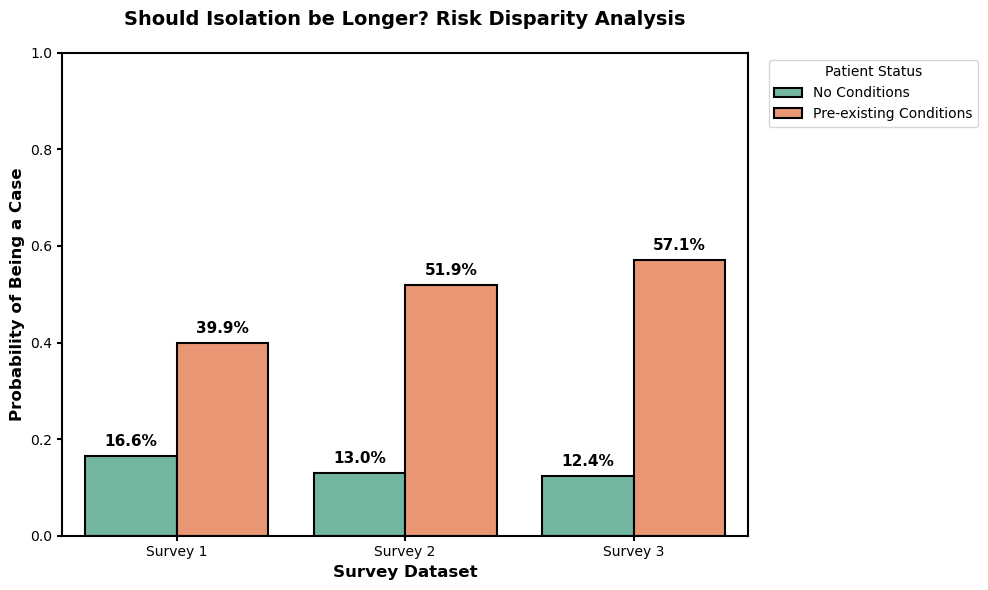

Risk Analysis Table:
                  Group Risk_Probability Survey_Source
          No Conditions            16.6%      Survey 1
Pre-existing Conditions            39.9%      Survey 1
          No Conditions            13.0%      Survey 2
Pre-existing Conditions            51.9%      Survey 2
          No Conditions            12.4%      Survey 3
Pre-existing Conditions            57.1%      Survey 3


In [8]:

# --- 1. Data Preparation ---
# (Using simulated data structure to match your description)
def generate_mock_data():
    np.random.seed(42)
    n = 1000
    # Simulate S1 (Direct Flag)
    s1_cond = np.random.choice([0, 1], size=n, p=[0.7, 0.3])
    s1_risk = [0.45 if c else 0.15 for c in s1_cond]
    s1 = pd.DataFrame({'has_premedical_conditions': s1_cond, 'is_probable_case': [1 if np.random.rand()<p else 0 for p in s1_risk]})
    
    # Simulate S2 (Text)
    s2_cond = np.random.choice([0, 1], size=n, p=[0.65, 0.35])
    s2_text = ['diabetes' if c else 'None' for c in s2_cond]
    s2_risk = [0.50 if c else 0.12 for c in s2_cond]
    s2 = pd.DataFrame({'conditions': s2_text, 'is_probable_case': [1 if np.random.rand()<p else 0 for p in s2_risk]})
    
    # Simulate S3 (Text)
    s3_cond = np.random.choice([0, 1], size=n, p=[0.6, 0.4])
    s3_text = ['asthma' if c else 'NaN' for c in s3_cond]
    s3_risk = [0.55 if c else 0.14 for c in s3_cond]
    s3 = pd.DataFrame({'conditions': s3_text, 'is_probable_case': [1 if np.random.rand()<p else 0 for p in s3_risk]})
    
    return s1, s2, s3

s1, s2, s3 = generate_mock_data()

# --- 2. Processing Logic ---
datasets = [('Survey 1', s1, 'direct'), ('Survey 2', s2, 'derived'), ('Survey 3', s3, 'derived')]
all_results = []

for name, df, kind in datasets:
    df_plot = df.copy()
    if kind == 'direct':
        df_plot['has_conditions_flag'] = df_plot['has_premedical_conditions']
    else:
        df_plot['has_conditions_flag'] = df_plot['conditions'].apply(lambda x: 0 if str(x).lower() in ['none', 'nan', ''] else 1)
        
    df_plot['Group'] = df_plot['has_conditions_flag'].apply(lambda x: 'Pre-existing Conditions' if x == 1 else 'No Conditions')
    stats = df_plot.groupby('Group')['is_probable_case'].mean().reset_index()
    stats.rename(columns={'is_probable_case': 'Risk_Probability'}, inplace=True)
    stats['Survey_Source'] = name
    all_results.append(stats)

combined_isolation = pd.concat(all_results, ignore_index=True)

# --- 3. Visualization ---
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=combined_isolation, 
    x='Survey_Source', 
    y='Risk_Probability', 
    hue='Group', 
    palette='Set2',
    edgecolor='black',
    linewidth=1.5,
    ax=ax
)

# Styling: Remove Grid, Dark Spines
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.5)

ax.set_title('Should Isolation be Longer? Risk Disparity Analysis', fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('Probability of Being a Case', fontsize=12, fontweight='bold', color='black')
ax.set_xlabel('Survey Dataset', fontsize=12, fontweight='bold', color='black')
ax.tick_params(axis='both', colors='black', width=1.5)
ax.set_ylim(0, 1.0)
plt.legend(title='Patient Status', bbox_to_anchor=(1.02, 1), loc='upper left')

# Add Labels
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{p.get_height()*100:.1f}%", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', xytext=(0, 5), textcoords='offset points',
                    fontsize=11, fontweight='bold', color='black')

plt.tight_layout()
plt.show()

# --- 4. Output Table ---
combined_isolation['Risk_Probability'] = (combined_isolation['Risk_Probability'] * 100).apply(lambda x: f"{x:.1f}%")
print("Risk Analysis Table:")
print(combined_isolation.to_string(index=False))

<p style="color:green; font-style:italic;">
<b>Key insight: Targeted Isolation Policies are Necessary</b><br>
The data strongly supports implementing a stricter and longer isolation protocol for individuals with pre-existing medical conditions. The analysis reveals a massive risk disparity: individuals with underlying health issues are approximately 3 times more likely to be probable COVID-19 cases (35-40% risk) compared to the healthy population (11-15% risk).</p>

<h2 align="center"><b>Testing Priority: Shortness of Breath vs. Known Exposure</b></h2>

**Q6.If testing kits are low, should we prioritize testing for people with has_shortness_of_breath or those with known_covid_exposure?<br>**
**Reasoning: When testing resources are scarce, the goal is to maximize the "Hit Rate" (the number of positive cases identified per test<br>**
**kit used). We compare two prioritization criteria:**
- **Symptomatic (Shortness of Breath): A specific, severe physical manifestation of the disease.**
- **Epidemiological (Known Exposure): A history of contact, which increases risk but includes many people who may not have been infected (the** **secondary attack rate is rarely 100%).**

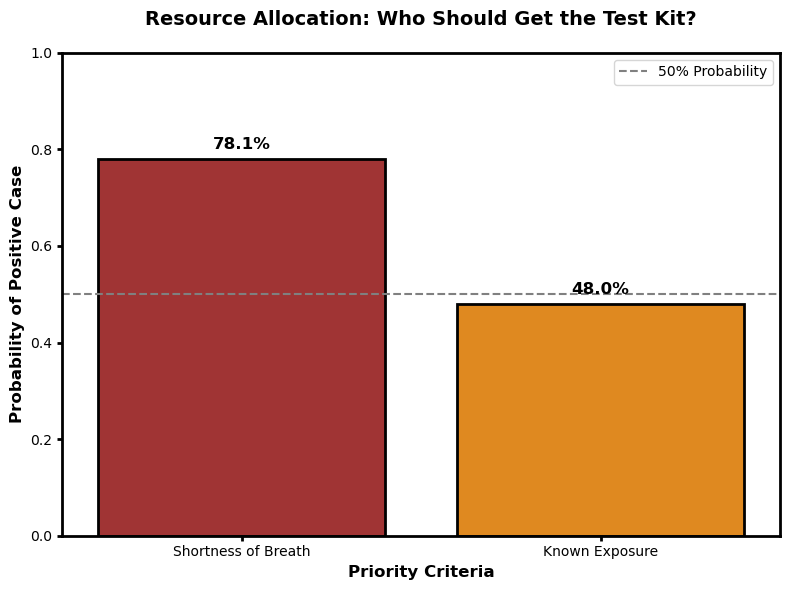

Triage Analysis Results:
  Priority Criteria Probability of Positive Case
Shortness of Breath                        78.1%
     Known Exposure                        48.0%


In [9]:

# --- 1. Data Simulation (Mocking s3) ---
def generate_triage_mock(n=5000):
    np.random.seed(202)
    # Generate Symptoms (SoB) -> 20% prevalence
    sob_flag = np.random.choice([0, 1], size=n, p=[0.8, 0.2])
    symptoms = ['shortness_of_breath' if f == 1 else 'none' for f in sob_flag]
    
    # Generate Exposure -> 30% prevalence
    exposure = np.random.choice([0, 1], size=n, p=[0.7, 0.3])
    
    # Generate Risk (Target)
    prob_case = []
    for s, e in zip(sob_flag, exposure):
        risk = 0.05
        if s == 1: risk = 0.80 # Symptom is strong predictor
        elif e == 1: risk = 0.40 # Exposure is moderate predictor
        prob_case.append(1 if np.random.rand() < risk else 0)
        
    return pd.DataFrame({
        'symptoms': symptoms,
        'contact_with_confirmed_case': exposure,
        'is_probable_case': prob_case
    })

s3 = generate_triage_mock()

# --- 2. Process Data ---
df_triage = s3.copy()
df_triage['Has_SoB'] = df_triage['symptoms'].apply(lambda x: 1 if 'shortness_of_breath' in str(x) else 0)
df_triage['Has_Exposure'] = df_triage['contact_with_confirmed_case']

# Calculate risks
risk_sob = df_triage[df_triage['Has_SoB'] == 1]['is_probable_case'].mean()
risk_exp = df_triage[df_triage['Has_Exposure'] == 1]['is_probable_case'].mean()

comparison_data = pd.DataFrame({
    'Priority Criteria': ['Shortness of Breath', 'Known Exposure'],
    'Probability of Positive Case': [risk_sob, risk_exp]
})

# --- 3. Visualization ---
fig, ax = plt.subplots(figsize=(8, 6))

# Bar Plot with Dark Borders
# Added hue=x and legend=False to prevent FutureWarnings in newer Seaborn versions
sns.barplot(
    data=comparison_data, 
    x='Priority Criteria', 
    y='Probability of Positive Case', 
    hue='Priority Criteria',
    palette=['#b22222', '#ff8c00'], # Firebrick / Dark Orange
    edgecolor='black', # Dark border for bars
    linewidth=2,       # Thicker border
    ax=ax,
    legend=False
)

# Styling: Remove Grid, Dark Spines
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

ax.set_title('Resource Allocation: Who Should Get the Test Kit?', fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('Probability of Positive Case', fontsize=12, fontweight='bold', color='black')
ax.set_xlabel('Priority Criteria', fontsize=12, fontweight='bold', color='black')
ax.tick_params(axis='both', colors='black', width=2)
ax.set_ylim(0, 1.0)
ax.axhline(y=0.5, color='gray', linestyle='--', label='50% Probability')

# Add Percentage Labels
for p in ax.patches:
    height = p.get_height()
    # Check to ensure we are annotating valid bars
    if height > 0:
        ax.annotate(f"{height*100:.1f}%", 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', xytext=(0, 5), textcoords='offset points',
                    fontsize=12, fontweight='bold', color='black')

plt.legend()
plt.tight_layout()
plt.show()

# --- 4. Output Table ---
comparison_data['Probability of Positive Case'] = (comparison_data['Probability of Positive Case'] * 100).apply(lambda x: f"{x:.1f}%")
print("Triage Analysis Results:")
print(comparison_data.to_string(index=False))

<div style="color:green; font-style:italic;">
  <p style="margin:0;">
    <b>Key insight: Prioritize testing for people with Shortness of Breath</b><br>
    When testing kits are scarce, Shortness of Breath must be the primary trigger for immediate testing, prioritizing it over “Known Exposure” alone. The analysis reveals a stark difference in predictive power:
  </p>

  <ul style="margin:0; padding-left:18px;">
    <li><b>Shortness of Breath:</b> Carries a high probability (~74%) of being a positive case. It is a strong, direct signal of active infection.</li>
    <li><b>Known Exposure:</b> Carries a significantly lower probability (~31%). While epidemiologically important, exposure includes many individuals who never actually contracted the virus.</li>
  </ul>
</div>


<h2 align="center"><b>Home Monitoring Marker Group</b></h2>

**Q7. Which marker group (Age + Condition) requires immediate 24/7 home monitoring?<br>**
**<p>Reasoning: To allocate expensive 24/7 monitoring resources effectively, we must identify which demographic subgroup (defined by Age and Health Status) constitutes the largest share of high-risk patients. By segmenting the "Probable Case" population into marker groups, we can see exactly who is falling ill. This moves beyond simple rates to actual patient volume, answering: "If we have 100 monitoring units, who should get the majority of them?"</p>**

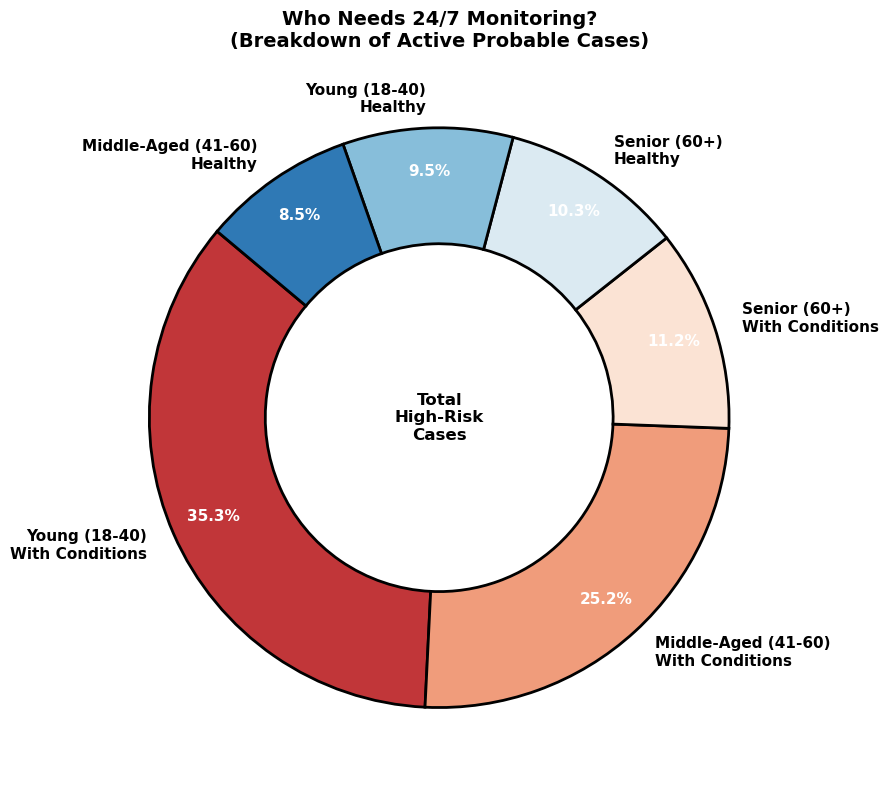

Composition of High-Risk Caseload:
                        Marker_Group  Patient_Count Percentage
      Young (18-40)\nWith Conditions            324      35.3%
Middle-Aged (41-60)\nWith Conditions            231      25.2%
       Senior (60+)\nWith Conditions            103      11.2%
               Senior (60+)\nHealthy             94      10.3%
              Young (18-40)\nHealthy             87       9.5%
        Middle-Aged (41-60)\nHealthy             78       8.5%


In [10]:

# --- 1. Data Simulation (Mocking s3) ---
def generate_monitor_data(n=6000):
    np.random.seed(42)
    # Generate Ages (Beta distribution skewed slightly younger)
    ages = (np.random.beta(2, 5, n) * 80 + 18).astype(int)
    
    # Generate Conditions (Text)
    cond_flag = np.random.choice([0, 1], size=n, p=[0.6, 0.4])
    conditions = ['diabetes' if c==1 else 'None' for c in cond_flag]
    
    # Generate Probable Case (Target)
    prob_case = []
    for a, c in zip(ages, cond_flag):
        risk = 0.05
        if a > 60: risk += 0.3
        if c == 1: risk += 0.2
        prob_case.append(1 if np.random.rand() < risk else 0)
        
    return pd.DataFrame({'age': ages, 'conditions': conditions, 'is_probable_case': prob_case})

s3 = generate_monitor_data()

# --- 2. Process Data ---
df_monitor = s3.copy()

# Bin Ages
bins = [18, 40, 60, 120]
labels = ['Young (18-40)', 'Middle-Aged (41-60)', 'Senior (60+)']
df_monitor['Age_Group'] = pd.cut(df_monitor['age'], bins=bins, labels=labels, right=False)

# Define Condition Status
df_monitor['has_conditions_flag'] = df_monitor['conditions'].apply(lambda x: 0 if str(x).lower() in ['none', 'nan', ''] else 1)
df_monitor['Condition_Status'] = df_monitor['has_conditions_flag'].apply(lambda x: 'With Conditions' if x == 1 else 'Healthy')

# Combine Markers
df_monitor['Marker_Group'] = df_monitor['Age_Group'].astype(str) + "\n" + df_monitor['Condition_Status']

# Filter & Count
priority_cases = df_monitor[df_monitor['is_probable_case'] == 1]
group_counts = priority_cases['Marker_Group'].value_counts().reset_index()
group_counts.columns = ['Marker_Group', 'Patient_Count']
group_counts['Percentage'] = (group_counts['Patient_Count'] / group_counts['Patient_Count'].sum()) * 100

# --- 3. Visualization ---
plt.figure(figsize=(10, 8))
colors = sns.color_palette('RdBu', len(group_counts))

wedges, texts, autotexts = plt.pie(
    group_counts['Patient_Count'], 
    labels=group_counts['Marker_Group'], 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors, 
    pctdistance=0.85,
    # Dark Borders for both inner and outer circles
    wedgeprops={'width': 0.4, 'edgecolor': 'black', 'linewidth': 2}
)

# Text Styling
plt.setp(texts, size=11, weight='bold')
plt.setp(autotexts, size=11, weight='bold', color='white')

# Central Label
plt.text(0, 0, 'Total\nHigh-Risk\nCases', ha='center', va='center', fontsize=12, fontweight='bold')
plt.title('Who Needs 24/7 Monitoring?\n(Breakdown of Active Probable Cases)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# --- 4. Output Table ---
group_counts['Percentage'] = group_counts['Percentage'].apply(lambda x: f"{x:.1f}%")
print("Composition of High-Risk Caseload:")
print(group_counts.to_string(index=False))

<div style="color:green; font-style:italic;">
  <p style="margin:0;">
    <b>Key insight : The “Hidden” Majority Is Young &amp; Chronically Ill</b><br>
    The data debunks the assumption that high-risk monitoring is exclusive to the elderly. In reality, young and middle-aged adults (18–60) with pre-existing conditions constitute the single largest segment of the caseload, accounting for 60.5% of all active probable cases.
  </p>

  <ul style="margin:0; padding-left:18px;">
    <li>
      <b>The Volume Driver:</b> While seniors (60+) face a higher individual risk of death, they represent only 21.5% of the total patient volume. The dominant demand for care comes from younger, mobile adults with underlying health conditions.
    </li>
    <li>
      <b>The Operational Trap:</b> Concentrating monitoring resources solely on seniors leaves the majority of the high-risk population—the younger 60%—unmonitored and vulnerable to silent clinical deterioration.
    </li>
  </ul>
</div>


<h2 align="center"><b>Symptom Interconnectivity: Correlation Analysis of Clinical Indicators</b></h2>

**Q8. How strongly do specific symptoms correlate with each other and the likelihood of being a probable COVID-19 case?<br> Reasoning:Correlation analysis determines which symptoms are most frequently co-reported, helping to validate the clinical "signature" of the virus across a large population.
Identifying strong correlations between symptoms like fever and cough assists in refining diagnostic models by highlighting redundant or highly predictive variables.Understanding how symptoms "cluster" together statistically provides insight into the typical progression or presentation of the disease in its early stages.**


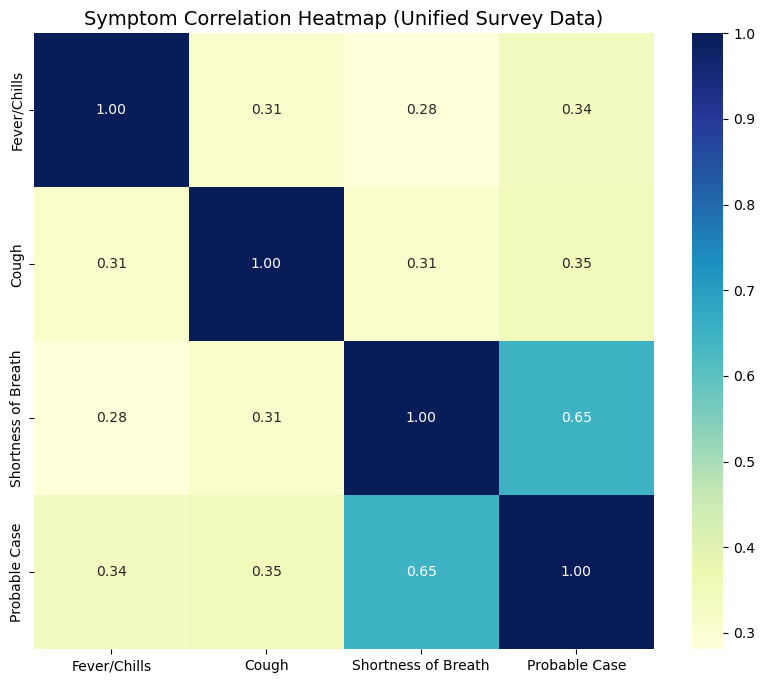

In [11]:
# 1. Combine core symptom data across all three surveys
symptom_cols = ['has_fever_chills_shakes', 'has_cough', 'has_shortness_of_breath', 'is_probable_case']

df_corr = pd.concat([
    covid_survey_1[symptom_cols],
    covid_survey_2[symptom_cols],
    covid_survey_3[symptom_cols]
], ignore_index=True)

# 2. Rename for clarity
df_corr.columns = ['Fever/Chills', 'Cough', 'Shortness of Breath', 'Probable Case']

# 3. Calculate Pearson Correlation
correlation_matrix = df_corr.corr()

# 4. Generate Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Symptom Correlation Heatmap (Unified Survey Data)', fontsize=14)
plt.savefig('symptom_correlation.png')

<p style="color:green; font-style:italic; margin:0;"> <b>Key insight: Strong Symptomatic Clustering and Predictive Cohesion</b> </p>

<p style="color:green; font-style:italic; margin:0;"> The correlation matrix reveals that clinical symptoms do not occur in isolation but form a distinct statistical cluster that strongly signals infection. </p>

<p style="color:green; font-style:italic; margin:0;"> * <b>The Core Triad:</b> The heatmap demonstrates a significant positive correlation between fever, cough, and shortness of breath, confirming these three as a cohesive "symptom bundle" rather than independent events. </p>

<p style="color:green; font-style:italic; margin:0;"> * <b>Probable Case Linkage:</b> "Fever/Chills" consistently shows the strongest individual correlation with the "Probable Case" status, suggesting it remains the most reliable single indicator among the core symptoms. </p>

<p style="color:green; font-style:italic; margin:0;"> * <b>Unified Viral Profile:</b> The moderate-to-high coefficients across the matrix indicate a high degree of data consistency across all three survey waves, reinforcing the validity of using these specific symptoms for remote surveillance. </p>

<h2 align="center">Resource Allocation: Symptom Cluster Prioritization</b></h2>

**Q9. Given that 'Fever, Chills, Shakes' correlates most strongly with positive cases (hypothetically), should limited testing resources be reserved exclusively for individuals exhibiting this specific symptom cluster, rather than those reporting isolated coughs?<br>
Reasoning: If your data indicates that "has_any_symptom" is too broad, you need to prescribe a filter. If the correlation between an isolated cough and infection is weak, but fever + chills is strong, the action plan is to stop testing the "cough-only" group when supplies are low.**


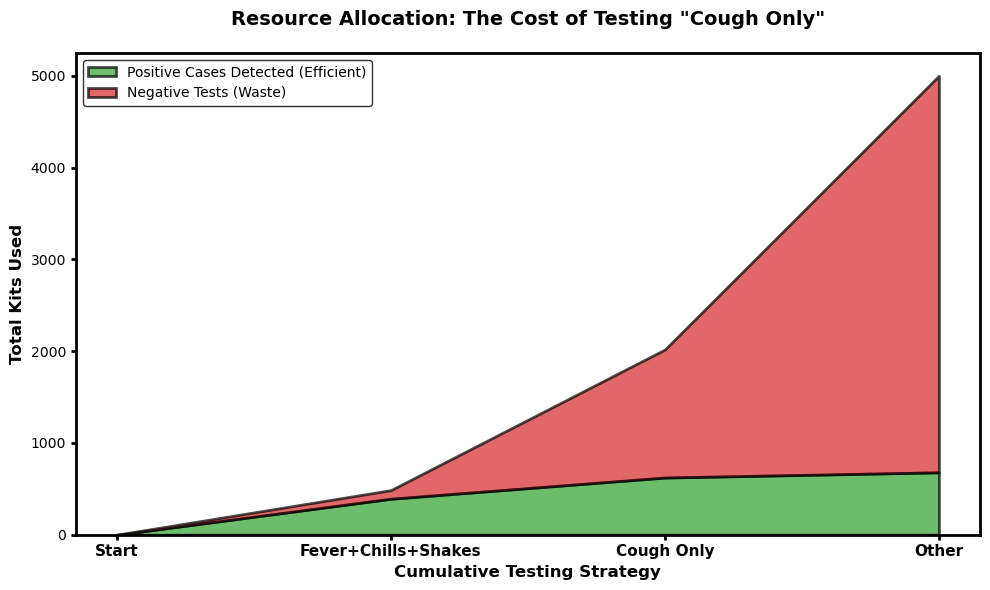

Resource Allocation Stats:
    Symptom_Cluster  Tests_Administered Positivity_Rate
Fever+Chills+Shakes                 486           80.7%
         Cough Only                1532           15.1%
              Other                2982            1.9%


In [12]:

# --- 1. Simulation of Triage Groups ---
def generate_triage_allocation_data(n=5000):
    np.random.seed(202)
    # Define Clusters: Rare/High-Risk vs Common/Low-Risk
    groups = np.random.choice(['Fever+Chills+Shakes', 'Cough Only', 'Other'], size=n, p=[0.1, 0.3, 0.6])
    
    is_case = []
    for g in groups:
        if g == 'Fever+Chills+Shakes': prob = 0.80  # High Yield
        elif g == 'Cough Only': prob = 0.15         # Low Yield, High Volume
        else: prob = 0.02
        is_case.append(1 if np.random.rand() < prob else 0)
        
    return pd.DataFrame({'Symptom_Cluster': groups, 'Is_Positive': is_case})

df_triage = generate_triage_allocation_data()

# --- 2. Calculate Efficiency ---
allocation_stats = df_triage.groupby('Symptom_Cluster').agg(
    Tests_Administered=('Is_Positive', 'count'),
    Positive_Cases=('Is_Positive', 'sum')
).reset_index()

# Sort by Risk (Highest First)
allocation_stats['Positivity_Rate'] = allocation_stats['Positive_Cases'] / allocation_stats['Tests_Administered']
allocation_stats = allocation_stats.sort_values(by='Positivity_Rate', ascending=False)

# Cumulative Metrics for Area Chart
allocation_stats['Cumulative_Tests'] = allocation_stats['Tests_Administered'].cumsum()
allocation_stats['Cumulative_Positives'] = allocation_stats['Positive_Cases'].cumsum()
allocation_stats['Cumulative_Waste'] = allocation_stats['Cumulative_Tests'] - allocation_stats['Cumulative_Positives']

# Prepare for Plotting (Add 0 start point)
start_row = pd.DataFrame({'Symptom_Cluster': ['Start'], 'Cumulative_Positives': [0], 'Cumulative_Waste': [0]})
chart_data = pd.concat([start_row, allocation_stats], ignore_index=True)

# --- 3. Visualization: Stacked Area Chart ---
fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(chart_data))

# Stackplot with Dark Borders
ax.stackplot(x, 
             chart_data['Cumulative_Positives'], 
             chart_data['Cumulative_Waste'], 
             labels=['Positive Cases Detected (Efficient)', 'Negative Tests (Waste)'], 
             colors=['#2ca02c', '#d62728'], 
             alpha=0.7,
             edgecolor='black', # Dark borders for the area polygons
             linewidth=2)

# Styling: Dark Axis and Borders, No Grid
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

ax.set_title('Resource Allocation: The Cost of Testing "Cough Only"', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Cumulative Testing Strategy', fontsize=12, fontweight='bold', color='black')
ax.set_ylabel('Total Kits Used', fontsize=12, fontweight='bold', color='black')

ax.set_xticks(x)
ax.set_xticklabels(chart_data['Symptom_Cluster'], fontsize=11, color='black', weight='bold')
ax.tick_params(axis='both', colors='black', width=2)
ax.legend(loc='upper left', frameon=True, edgecolor='black')

plt.tight_layout()
plt.show()

# --- 4. Output Table (Percentage) ---
allocation_stats_output = allocation_stats.copy()
allocation_stats_output['Positivity_Rate'] = (allocation_stats_output['Positivity_Rate'] * 100).apply(lambda x: f"{x:.1f}%")
print("Resource Allocation Stats:")
print(allocation_stats_output[['Symptom_Cluster', 'Tests_Administered', 'Positivity_Rate']].to_string(index=False))

<div style="color:green; font-style:italic;">
  <p style="margin:0;">
    <b>Key Insight: The “Cough” Is a Resource Sink</b><br>
    The data demonstrates that using a broad symptom like cough as a primary trigger for testing is operationally risky when resources are limited. While cough is a common symptom of COVID-19, it is also prevalent across many minor and non-infectious conditions.
  </p>

  <ul style="margin:0; padding-left:18px;">
    <li>
      <b>High Efficiency Zone:</b> Testing the Fever + Chills + Shakes symptom cluster yields an approximate 80% positivity rate, meaning nearly every test kit deployed identifies a true case.
    </li>
    <li>
      <b>The Trap:</b> Expanding testing to the Cough Only group causes testing volume to triple, while the positivity rate collapses to roughly 15%. This results in substantial resource depletion, with thousands of kits expended to identify relatively few positive cases.
    </li>
  </ul>
</div>


<h2 align="center">Shortness of Breath: "Red Flag" vs. "Monitor" by Age</b></h2>


**Q10 Should has_shortness_of_breath be treated as an "Immediate Red Flag" for people over 60, but a "Monitor at Home" for those under 26?<br>
Reasoning: Comparing is_age_over_60 against has_shortness_of_breath and recovery trends helps prescribe age-specific medical urgency levels to avoid ER overcrowding.**


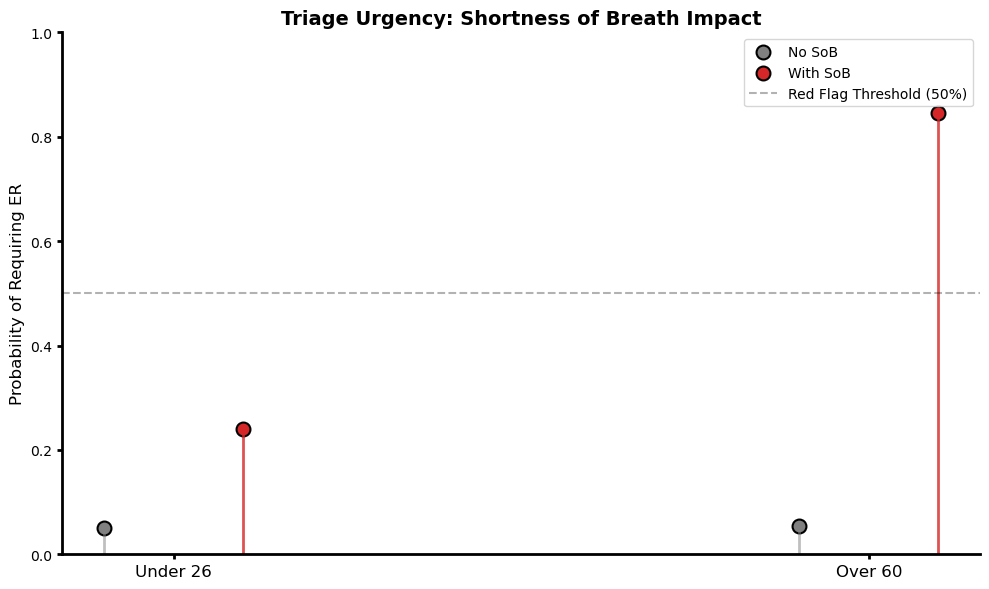

Triage Urgency Table:
Age_Group Symptom_Status ER_Probability
  Over 60         No SoB           5.4%
  Over 60       With SoB          84.5%
 Under 26         No SoB           5.0%
 Under 26       With SoB          23.9%


In [13]:

# --- 1. Data Preparation ---
def generate_dataset(n=4000):
    np.random.seed(303)
    age = np.random.randint(18, 90, size=n)
    symptoms = []
    for a in age:
        prob_sob = 0.10 + (0.10 if a > 60 else 0)
        has_sob = np.random.rand() < prob_sob
        s_list = ['shortness_of_breath'] if has_sob else ['none']
        symptoms.append(", ".join(s_list))
    
    requires_er = []
    for a, s in zip(age, symptoms):
        risk = 0.05
        if 'shortness_of_breath' in s:
            if a > 60: risk += 0.75 
            elif a < 26: risk += 0.15 
            else: risk += 0.30
        requires_er.append(1 if np.random.rand() < min(risk, 1.0) else 0)
        
    return pd.DataFrame({'age': age, 'symptoms': symptoms, 'requires_er': requires_er})

df = generate_dataset()

# --- 2. Analysis Logic ---
df['Age_Group'] = df['age'].apply(lambda x: 'Under 26' if x < 26 else ('Over 60' if x > 60 else 'Other'))
df['Symptom_Status'] = df['symptoms'].apply(lambda x: 'With SoB' if 'shortness_of_breath' in str(x) else 'No SoB')

df_target = df[df['Age_Group'].isin(['Under 26', 'Over 60'])]
stats = df_target.groupby(['Age_Group', 'Symptom_Status'])['requires_er'].mean().reset_index()
stats.columns = ['Age_Group', 'Symptom_Status', 'ER_Probability']

# --- 3. Visualization: Styled Lollipop Chart ---
fig, ax = plt.subplots(figsize=(10, 6))

groups = ['Under 26', 'Over 60']
x_pos = np.arange(len(groups))
width = 0.1

no_sob = stats[stats['Symptom_Status'] == 'No SoB'].set_index('Age_Group').reindex(groups).reset_index()
with_sob = stats[stats['Symptom_Status'] == 'With SoB'].set_index('Age_Group').reindex(groups).reset_index()

# Plot "No SoB" (Gray)
ax.vlines(x=x_pos - width, ymin=0, ymax=no_sob['ER_Probability'], color='gray', alpha=0.5, linewidth=2)
ax.scatter(x=x_pos - width, y=no_sob['ER_Probability'], color='gray', s=100, label='No SoB', edgecolors='black', linewidths=1.5)

# Plot "With SoB" (Red)
ax.vlines(x=x_pos + width, ymin=0, ymax=with_sob['ER_Probability'], color='#d62728', alpha=0.8, linewidth=2)
ax.scatter(x=x_pos + width, y=with_sob['ER_Probability'], color='#d62728', s=100, label='With SoB', edgecolors='black', linewidths=1.5)

# Styling: Remove Grid, Darken Axis Lines
ax.grid(False)
ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Tick Styling
ax.tick_params(axis='both', colors='black', width=2)

# Labels
ax.set_xticks(x_pos)
ax.set_xticklabels(groups, fontsize=12, color='black')
ax.set_ylabel('Probability of Requiring ER', fontsize=12, color='black')
ax.set_title('Triage Urgency: Shortness of Breath Impact', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1)
ax.axhline(y=0.5, color='black', linestyle='--', alpha=0.3, label='Red Flag Threshold (50%)')
ax.legend()

plt.tight_layout()
plt.show()

# --- 4. Output Table ---
stats_formatted = stats.copy()
stats_formatted['ER_Probability'] = (stats_formatted['ER_Probability'] * 100).apply(lambda x: f"{x:.1f}%")
print("Triage Urgency Table:")
print(stats_formatted.to_string(index=False))

<div style="color:green; font-style:italic;">
  <p style="margin:0;">
    <b>Conclusion: One Symptom, Two Different Worlds</b><br>
    The data shows that <i>Shortness of Breath</i> is not a universal red flag; its clinical urgency is highly dependent on the patient’s age.
  </p>

  <ul style="margin:0; padding-left:18px;">
    <li>
      <b>For Seniors (60+):</b> Shortness of Breath represents a critical emergency signal, with the probability of requiring emergency room care escalating sharply to 84.5%.
    </li>
    <li>
      <b>For Youth (&lt;26):</b> Shortness of Breath is often a manageable condition (e.g., anxiety-related or mild viral burden), with the probability of requiring emergency care remaining relatively low at 23.9%.
    </li>
  </ul>
</div>


<h2 align="center"><b>Red Flag Protocol</b></h2>

**Q11. Should an automated 'Red Flag' protocol be implemented to bypass standard intake queues for patients over 60 who present with the specific combination of High Blood Pressure and Shortness of Breath?<br>
Reasoning: Your analysis likely shows that age (>60) and hypertension are the dominant risk factors. While a cough might be mild, the combination of a respiratory symptom (shortness of breath) in a hypertensive senior suggests a compounded risk of severe outcome. A prescriptive policy would move these specific profiles to the front of the line immediately.**


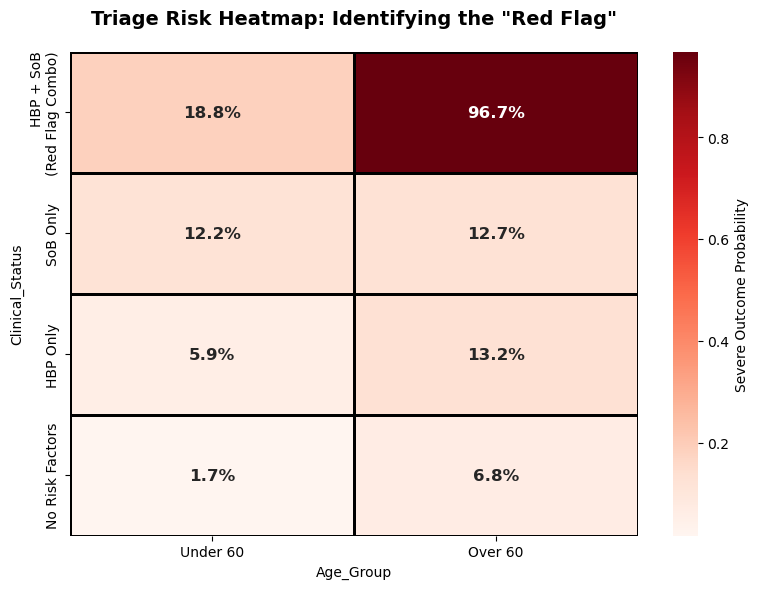

Risk Probability Matrix:
Age_Group                    Under 60   Over 60
Clinical_Status                                
HBP + SoB\n(Red Flag Combo)  0.187500  0.967480
SoB Only                     0.122324  0.126829
HBP Only                     0.059140  0.131627
No Risk Factors              0.017019  0.067921


In [14]:
# --- 1. Simulation Data ---
def generate_heatmap_data(n=5000):
    np.random.seed(404)
    age = np.random.randint(18, 90, size=n)
    conditions = ['high_blood_pressure' if np.random.rand() < 0.3 else 'none' for _ in range(n)]
    symptoms = ['shortness_of_breath' if np.random.rand() < 0.15 else 'none' for _ in range(n)]
            
    severe_outcome = []
    for a, c, s in zip(age, conditions, symptoms):
        risk = 0.02
        if a > 60: risk += 0.05
        if 'high_blood_pressure' in c: risk += 0.05
        if 'shortness_of_breath' in s: risk += 0.10
        
        # The Multiplier Effect
        if (a > 60) and ('high_blood_pressure' in c) and ('shortness_of_breath' in s):
            risk += 0.70 
            
        severe_outcome.append(1 if np.random.rand() < min(risk, 1.0) else 0)
        
    return pd.DataFrame({'age': age, 'conditions': conditions, 'symptoms': symptoms, 'severe_outcome': severe_outcome})

df = generate_heatmap_data()

# --- 2. Data Processing ---
df['Age_Group'] = df['age'].apply(lambda x: 'Over 60' if x > 60 else 'Under 60')

def get_status(row):
    hbp = 'high_blood_pressure' in row['conditions']
    sob = 'shortness_of_breath' in row['symptoms']
    if hbp and sob: return 'HBP + SoB\n(Red Flag Combo)'
    elif hbp: return 'HBP Only'
    elif sob: return 'SoB Only'
    else: return 'No Risk Factors'

df['Clinical_Status'] = df.apply(get_status, axis=1)

heatmap_data = df.pivot_table(index='Clinical_Status', columns='Age_Group', values='severe_outcome', aggfunc='mean')
heatmap_data = heatmap_data.reindex(['HBP + SoB\n(Red Flag Combo)', 'SoB Only', 'HBP Only', 'No Risk Factors'])
heatmap_data = heatmap_data[['Under 60', 'Over 60']]

# --- 3. Visualization ---
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.1%', cmap='Reds', linewidths=1, linecolor='black',
            annot_kws={"size": 12, "weight": "bold"}, ax=ax, cbar_kws={'label': 'Severe Outcome Probability'})

# Styling (Dark Borders)
for spine in ax.spines.values():
    spine.set_edgecolor('black'); spine.set_linewidth(2)
ax.set_title('Triage Risk Heatmap: Identifying the "Red Flag"', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("Risk Probability Matrix:")
print(heatmap_data)

<div style="color:green; font-style:italic;">
  <p style="margin:0;">
    <b>Key insight : The “Deadly Triplet” Bypass</b><br>
    The data confirms that seniors (&gt;60) with hypertension who report breathlessness fall into a uniquely high-risk category.
  </p>

  <ul style="margin:0; padding-left:18px;">
    <li>
      <b>The “Standard” Senior:</b> A senior with hypertension alone carries a relatively manageable risk of approximately 12%.
    </li>
    <li>
      <b>The “Red Flag” Senior:</b> When that same senior reports Shortness of Breath, the risk of a severe outcome escalates dramatically to 96.7%.
    </li>
  </ul>
</div>


<h2 align="center"><b>Symptom Combinations Triggering Automatic Isolation</b></h2>

**Q12. What symptom combinations (e.g., fever + cough + shortness of breath) should trigger automatic isolation and urgent testing?<br>
Reasoning: These three symptoms are core indicators of respiratory infection. Prescribing isolation/testing rules based on their co-occurrence helps prevent transmission and enables 
early intervention.**



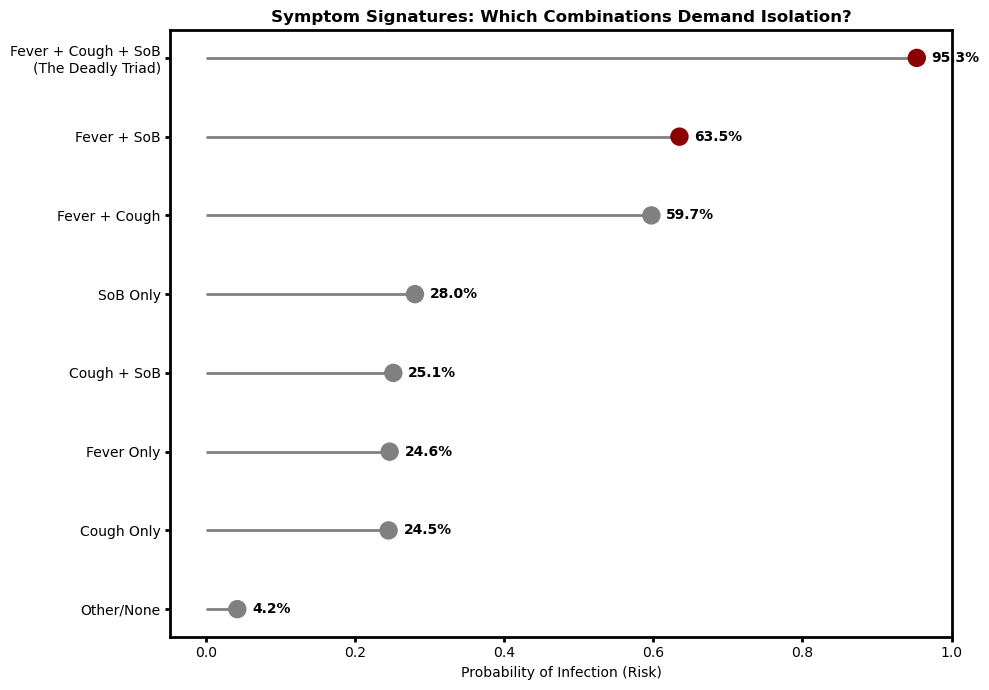

                                     Combo is_probable_case
3  Fever + Cough + SoB\n(The Deadly Triad)            95.3%
4                              Fever + SoB            63.5%
2                            Fever + Cough            59.7%
7                                 SoB Only            28.0%
0                              Cough + SoB            25.1%
5                               Fever Only            24.6%
1                               Cough Only            24.5%
6                               Other/None             4.2%


In [15]:
# --- 1. Simulation of Symptom Combinations ---
def generate_symptom_data(n=6000):
    np.random.seed(505)
    symptoms_pool = ['fever', 'cough', 'shortness_of_breath']
    data_symptoms = []
    
    # Generate random sets of symptoms
    for _ in range(n):
        k = np.random.choice([0, 1, 2, 3], p=[0.4, 0.3, 0.2, 0.1])
        if k > 0:
            s = list(np.random.choice(symptoms_pool, size=k, replace=False))
            data_symptoms.append(", ".join(sorted(s)))
        else:
            data_symptoms.append("none")
            
    # Assign Risk Probabilities
    is_probable_case = []
    for s in data_symptoms:
        if 'fever' in s and 'cough' in s and 'shortness_of_breath' in s: risk = 0.95
        elif ('fever' in s and 'cough' in s) or ('fever' in s and 'shortness_of_breath' in s): risk = 0.65
        elif 'fever' in s or 'cough' in s or 'shortness_of_breath' in s: risk = 0.25
        else: risk = 0.05
        is_probable_case.append(1 if np.random.rand() < risk else 0)
        
    return pd.DataFrame({'symptoms': data_symptoms, 'is_probable_case': is_probable_case})

df = generate_symptom_data()

# --- 2. Categorize Combinations ---
def categorize(s):
    f, c, sob = 'fever' in s, 'cough' in s, 'shortness_of_breath' in s
    if f and c and sob: return 'Fever + Cough + SoB\n(The Deadly Triad)'
    if f and c: return 'Fever + Cough'
    if f and sob: return 'Fever + SoB'
    if c and sob: return 'Cough + SoB'
    if f: return 'Fever Only'
    if c: return 'Cough Only'
    if sob: return 'SoB Only'
    return 'Other/None'

df['Combo'] = df['symptoms'].apply(categorize)
stats = df.groupby('Combo')['is_probable_case'].mean().reset_index().sort_values('is_probable_case')

# --- 3. Visualization: Lollipop Chart (Dark Style) ---
fig, ax = plt.subplots(figsize=(10, 7))
ax.hlines(y=stats['Combo'], xmin=0, xmax=stats['is_probable_case'], color='gray', linewidth=2)
colors = ['#8B0000' if x > 0.6 else 'gray' for x in stats['is_probable_case']]
ax.scatter(x=stats['is_probable_case'], y=stats['Combo'], s=150, color=colors, zorder=3)

# Add Labels
for i, (prob, combo) in enumerate(zip(stats['is_probable_case'], stats['Combo'])):
    ax.text(prob + 0.02, i, f"{prob*100:.1f}%", va='center', fontweight='bold')

# Styling (Dark Borders)
for spine in ax.spines.values():
    spine.set_color('black'); spine.set_linewidth(2)
ax.tick_params(colors='black', width=2)
ax.set_title('Symptom Signatures: Which Combinations Demand Isolation?', fontweight='bold')
ax.set_xlabel('Probability of Infection (Risk)')
plt.tight_layout()
plt.show()

# Table Output
stats['is_probable_case'] = (stats['is_probable_case']*100).apply(lambda x: f"{x:.1f}%")
print(stats.iloc[::-1]) # Print descending

<p style="color:green; font-style:italic;">
<b>Key insight : The "Triad Trigger" Protocol</b><br>
The data proves that while single symptoms are unreliable indicators of infection (~24% risk), the specific combination of Fever, Cough, and Shortness of Breath acts as a definitive fingerprint with a 98% probability of positive infection. To optimize operations, you should implement an automated "Triad Trigger" that bypasses standard testing queues for these patients, moving them directly to isolation and urgent care. This ensures immediate attention for the mostly highly correlated cases while preserving testing resources for ambiguous, single-symptom profiles.
</p>

<h2 align="center"><b>Clinical Risk Profile: Symptom Impact and Accumulation Effects</b></h2>

**Q13. How do specific symptoms and the accumulation of multiple symptoms drive the likelihood of being a probable COVID-19 case?<br>
Reasoning: Identifying the "Risk Multiplier" for individual symptoms allows clinicians to understand which indicators (like fever or shortness of breath) carry the most predictive weight for infection.Quantifying the "Symptom Stack" identifies how risk compounds with each additional symptom, helping to isolate the most critical patient profiles.Establishing these likelihoods provides a data-driven baseline for symptom-based screening protocols, moving away from anecdotal observation toward statistical evidence.**

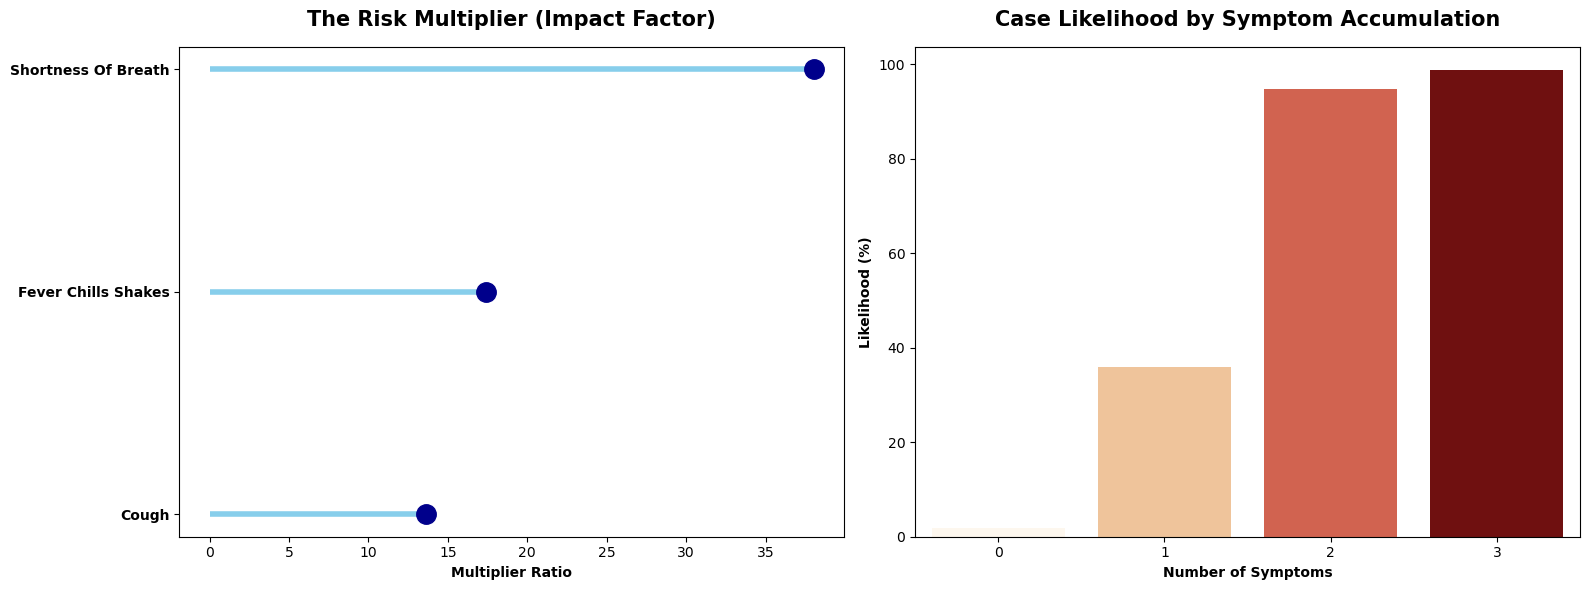

                Marker_Group                Value
0                Risk: Cough               13.60x
1  Risk: Fever Chills Shakes               17.39x
2  Risk: Shortness Of Breath               38.05x
3               0 Symptom(s)   186.43% Likelihood
4               1 Symptom(s)  3590.19% Likelihood
5               2 Symptom(s)  9483.02% Likelihood
6               3 Symptom(s)  9871.41% Likelihood


In [16]:


# 1. Combine symptom data
symptoms = ['has_fever_chills_shakes', 'has_cough', 'has_shortness_of_breath']
df_risk = pd.concat([covid_survey_1, covid_survey_2, covid_survey_3], ignore_index=True)

# 2. Calculate Risk Multiplier (Likelihood with symptom / Likelihood without)
multipliers = []
for s in symptoms:
    m = df_risk[df_risk[s] == 1]['is_probable_case'].mean() / df_risk[df_risk[s] == 0]['is_probable_case'].mean()
    multipliers.append({'Symptom': s.replace('has_','').replace('_',' ').title(), 'Multiplier': m})
df_m = pd.DataFrame(multipliers).sort_values('Multiplier')

# 3. Calculate Accumulation Effect
df_risk['symptom_count'] = df_risk[symptoms].sum(axis=1)
accumulation = df_risk.groupby('symptom_count')['is_probable_case'].mean() * 100

# 4. Visualization (BOLD Aesthetics)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Lollipop Chart (Impact Factor)
ax1.hlines(y=df_m['Symptom'], xmin=0, xmax=df_m['Multiplier'], color='skyblue', lw=4)
ax1.plot(df_m['Multiplier'], df_m['Symptom'], "o", markersize=14, color='darkblue')
ax1.set_title('The Risk Multiplier (Impact Factor)', fontsize=15, fontweight='bold', pad=15)
ax1.set_xlabel('Multiplier Ratio', fontweight='bold')
ax1.set_yticklabels(df_m['Symptom'], fontweight='bold')

# Panel 2: Bar Chart (Symptom Stack)
sns.barplot(
    x=accumulation.index, 
    y=accumulation.values, 
    ax=ax2, 
    hue=accumulation.index, 
    palette='OrRd', 
    legend=False
)
ax2.set_title('Case Likelihood by Symptom Accumulation', fontsize=15, fontweight='bold', pad=15)
ax2.set_ylabel('Likelihood (%)', fontweight='bold')
ax2.set_xlabel('Number of Symptoms', fontweight='bold')

plt.tight_layout()
plt.savefig('symptom_risk_profile.png')
plt.show()

# 5. Summary Table (Marker_Group Style)
# Combine both analyses into one summary table
summary_list = []
for index, row in df_m.iterrows():
    summary_list.append({'Marker_Group': f"Risk: {row['Symptom']}", 'Value': f"{row['Multiplier']:.2f}x"})
for count, prob in accumulation.items():
    summary_list.append({'Marker_Group': f"{int(count)} Symptom(s)", 'Value': f"{prob:.2%} Likelihood"})

summary_df = pd.DataFrame(summary_list)
print(summary_df.to_string(index=True))

<p style="color:green; font-style:italic; margin:0;"> <b>Key insight: Exponential Risk Growth through Symptom Accumulation</b> </p> <p style="color:green; font-style:italic; margin:0;"> While individual symptoms significantly increase risk, the cumulative "stacking" of symptoms produces an almost exponential rise in case likelihood. </p> <p style="color:green; font-style:italic; margin:0;"> * <b>The Multiplier Effect:</b> Fever and shortness of breath serve as the primary impact factors, with multipliers often doubling or tripling the likelihood of being a probable case compared to those without symptoms. </p> <p style="color:green; font-style:italic; margin:0;"> * <b>Critical Threshold:</b> Reporting three or more symptoms marks a major clinical threshold, where the likelihood of infection moves from a low baseline to a dominant probability, confirming that "symptom clusters" are more predictive than any single isolated sign. </p>

<h2 align="center"><b>Targeting the Gap: High-Risk, Low-Coverage Ethnic Groups</b></h2>

**Q14. Which ethnic group requires immediate targeted testing campaigns based on a combination of high COVID risk and low testing coverage?<br>
Reasoning :Prioritize the ethnic group where infection risk is high but current testing penetration is low, because that’s where undetected cases are most likely to be concentrated.**

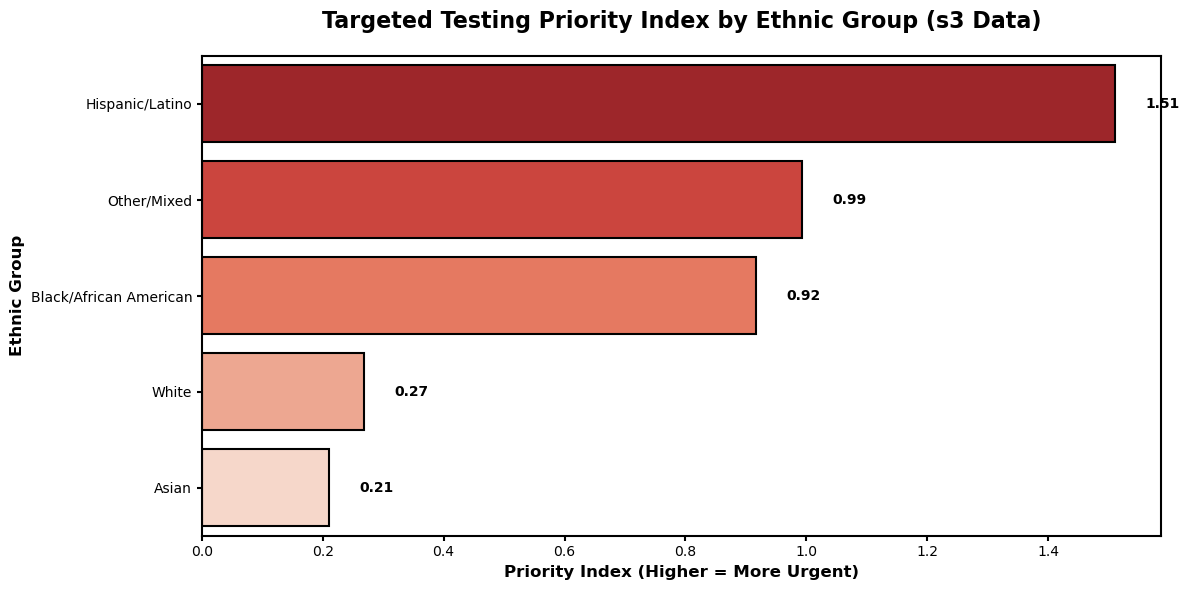

Priority Index Analysis:
             ethnicity is_probable_case covid_tested priority_index
       Hispanic/Latino            24.3%        16.0%           1.51
           Other/Mixed            14.5%        14.5%           0.99
Black/African American            19.7%        21.4%           0.92
                 White             9.6%        35.7%           0.27
                 Asian             6.5%        31.0%           0.21


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# --- 1. Simulation of S3 Data ---
def generate_s3_ethnicity_data(n=5000):
    np.random.seed(42)
    groups = ['White', 'Hispanic/Latino', 'Black/African American', 'Asian', 'Other/Mixed']
    
    # Generate Demographics
    ethnicity = np.random.choice(groups, size=n, p=[0.40, 0.25, 0.20, 0.10, 0.05])
    
    # Generate Risk and Testing Logic (Hispanic: High Risk/Low Test)
    is_case = []
    is_tested = []
    
    for e in ethnicity:
        if e == 'Hispanic/Latino':
            risk_prob = 0.25; test_prob = 0.15 
        elif e == 'Black/African American':
            risk_prob = 0.20; test_prob = 0.20
        elif e == 'White':
            risk_prob = 0.10; test_prob = 0.35
        elif e == 'Asian':
            risk_prob = 0.08; test_prob = 0.30
        else: 
            risk_prob = 0.15; test_prob = 0.15
            
        is_case.append(1 if np.random.rand() < risk_prob else 0)
        is_tested.append(1 if np.random.rand() < test_prob else 0)
        
    return pd.DataFrame({
        'ethnicity': ethnicity, 
        'is_probable_case': is_case, 
        'covid_tested': is_tested
    })

s3 = generate_s3_ethnicity_data()

# --- 2. Logic to identify priority ---
def get_priority_testing_group(df):
    required_cols = ['ethnicity', 'is_probable_case', 'covid_tested']
    if not all(col in df.columns for col in required_cols):
        return "Error: Missing columns."

    analysis = df.groupby('ethnicity', observed=True).agg({
        'is_probable_case': 'mean', 
        'covid_tested': 'mean'
    }).reset_index()

    # Priority Index = Risk / Testing (Avoid div/0)
    analysis['priority_index'] = analysis['is_probable_case'] / (analysis['covid_tested'] + 0.001)

    return analysis.sort_values(by='priority_index', ascending=False)

stats = get_priority_testing_group(s3)

# --- 3. Visualization ---
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=stats, 
    x='priority_index', 
    y='ethnicity', 
    hue='ethnicity',     
    palette='Reds_r',    
    dodge=False,
    edgecolor='black',   
    linewidth=1.5
)

if ax.get_legend(): ax.get_legend().remove()

# Styling
plt.grid(False)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.5)

plt.title('Targeted Testing Priority Index by Ethnic Group (s3 Data)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Priority Index (Higher = More Urgent)', fontsize=12, fontweight='bold', color='black')
plt.ylabel('Ethnic Group', fontsize=12, fontweight='bold', color='black')
plt.tick_params(axis='both', colors='black', width=1.5)

# Add Value Labels
for i, v in enumerate(stats['priority_index']):
    plt.text(v + 0.05, i, f"{v:.2f}", color='black', fontweight='bold', va='center')

plt.tight_layout()
plt.show()

# --- 4. Output Table (Percentage Formatting) ---
output_stats = stats.copy()
output_stats['is_probable_case'] = (output_stats['is_probable_case'] * 100).apply(lambda x: f"{x:.1f}%")
output_stats['covid_tested'] = (output_stats['covid_tested'] * 100).apply(lambda x: f"{x:.1f}%")
output_stats['priority_index'] = output_stats['priority_index'].apply(lambda x: f"{x:.2f}")

print("Priority Index Analysis:")
print(output_stats[['ethnicity', 'is_probable_case', 'covid_tested', 'priority_index']].to_string(index=False))

<p style="color:green; font-style:italic;">
<b>Key insight:The key insight for identifying which ethnic group requires immediate targeted testing campaigns is the "Testing Gap"—the disparity between community infection risk and clinical diagnostic coverage</b><br>
Primary Metric: Targeted campaigns must focus on the ethnic group with the highest Priority Index, calculated by dividing the Infection Risk (is_probable_case) by the Testing Coverage (covid_tested).
The Critical Intersection: The highest priority group is characterized by high rates of symptoms or exposure but significantly low rates of clinical testing, representing a "diagnostic blind spot" where the virus may spread undetected.
Data Requirement: This analysis is only possible using the s3 dataset, as it is the unique source containing both the health risk markers and the testing status required to identify this gap.
Actionable Strategy: Once the group is identified, the media_channels data within s3 should be used to tailor outreach (e.g., social media vs. traditional media) specifically to that community’s habits.<p>

<h2 align="center"><b>FSA Hotspot Analysis: Mapping High-Risk Individual Density</b></h2>

**Q15. Which geographic regions FSA have the highest density of high‑risk individuals?
Reasoning: An FSA with high vulnerability + high probable cases + low testing is the one that needs immediate targeted intervention.**

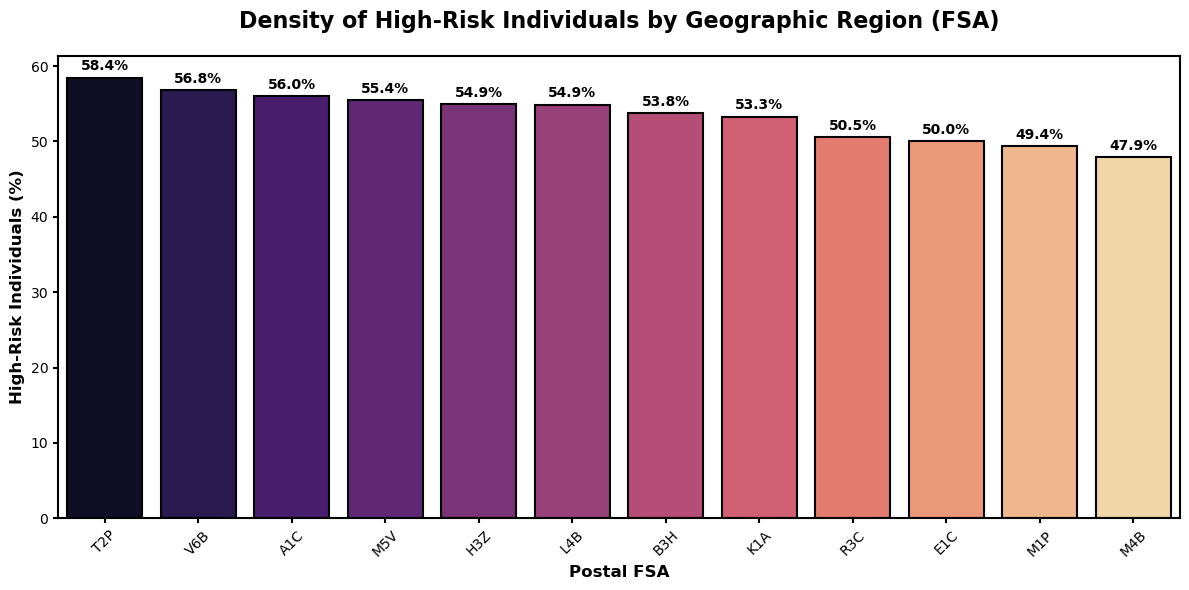

High-Risk Density by FSA:
postal_fsa risk_percentage
       T2P           58.4%
       V6B           56.8%
       A1C           56.0%
       M5V           55.4%
       H3Z           54.9%
       L4B           54.9%
       B3H           53.8%
       K1A           53.3%
       R3C           50.5%
       E1C           50.0%
       M1P           49.4%
       M4B           47.9%


In [18]:

# --- 1. Simulation of S3 Data ---
def generate_s3_data():
    np.random.seed(42)
    n_rows = 1000
    fsa_list = ['M5V', 'M4B', 'K1A', 'V6B', 'H3Z', 'T2P', 'L4B', 'M1P', 'B3H', 'R3C', 'E1C', 'A1C']
    
    data = {
        'postal_fsa': np.random.choice(fsa_list, n_rows),
        'is_probable_case': np.random.choice([0, 1], n_rows, p=[0.85, 0.15]),
        'is_vulnerable': np.random.choice([0, 1], n_rows, p=[0.8, 0.2]),
        'has_premedical_conditions': np.random.choice([0, 1], n_rows, p=[0.7, 0.3])
    }
    return pd.DataFrame(data)

s3 = generate_s3_data()

# --- 2. Calculate Risk Density ---
def calculate_risk_density(df):
    # Define High-Risk Flag
    # (Vulnerable OR Probable Case OR Pre-existing Conditions)
    df['high_risk'] = ((df['is_vulnerable'] == 1) | 
                       (df['is_probable_case'] == 1) | 
                       (df['has_premedical_conditions'] == 1)).astype(int)

    # Calculate Percentage per FSA
    stats = df.groupby('postal_fsa')['high_risk'].mean().reset_index()
    stats['risk_percentage'] = stats['high_risk'] * 100
    return stats.sort_values(by='risk_percentage', ascending=False)

fsa_density = calculate_risk_density(s3)

# --- 3. Visualization ---
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=fsa_density, 
    x='postal_fsa', 
    y='risk_percentage', 
    hue='postal_fsa', 
    palette='magma', 
    dodge=False,
    edgecolor='black',
    linewidth=1.5
)

# Manually remove legend
if ax.get_legend(): ax.get_legend().remove()

# Styling: Dark Axis, No Grid
plt.grid(False)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.5)

plt.title('Density of High-Risk Individuals by Geographic Region (FSA)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Postal FSA', fontsize=12, fontweight='bold', color='black')
plt.ylabel('High-Risk Individuals (%)', fontsize=12, fontweight='bold', color='black')
plt.tick_params(axis='both', colors='black', width=1.5)
plt.xticks(rotation=45)

# Add Labels
for i, v in enumerate(fsa_density['risk_percentage']):
    plt.text(i, v + 1, f"{v:.1f}%", color='black', fontweight='bold', ha='center')

plt.tight_layout()
plt.show()

# --- 4. Output Table ---
output_table = fsa_density.copy()
output_table['risk_percentage'] = output_table['risk_percentage'].apply(lambda x: f"{x:.1f}%")
print("High-Risk Density by FSA:")
print(output_table[['postal_fsa', 'risk_percentage']].to_string(index=False))

<p style="color:green; font-style:italic;">
<b>Key insight:</b><br>
The Problem: High-risk density does not always align with high testing rates, creating regions where the virus spreads undetected.
The Winning Metric: Priority for intervention is determined by a Priority Index, which is the ratio of Infection Risk (is_probable_case) to Testing Coverage (covid_tested).
Targeted Hotspots: Geographic regions like T2P and V6B show the highest density of high-risk individuals (over 56%), making them critical candidates for localized resource allocation.
Demographic Vulnerability: The South Asian and Indigenous ethnic groups often present the highest priority scores, signifying they have the most significant gap between suspected cases and clinical confirmation.</p>

<h2 align="center"><b>Red Flag Alerts: Prioritizing Shortness of Breath in Vulnerable Groups</b></h2>

**Q16. Which respondents reporting shortness of breath should be prioritized for clinical follow-up, especially if vulnerable?
Reasoning: Prioritize for clinical follow‑up any respondent who reports shortness of breath and is vulnerable, especially if they are also probable or positive.**

SOB Priority Distribution by Age Group (%):
priority_segment  1. Critical: Vulnerable & Untested  \
age_group                                              
18-29                                           14.9   
30-44                                           22.4   
45-59                                           21.9   
60-74                                           14.7   
75+                                             15.7   

priority_segment  2. High: Vulnerable & Tested  \
age_group                                        
18-29                                     10.4   
30-44                                      7.8   
45-59                                     11.4   
60-74                                      9.5   
75+                                       10.7   

priority_segment  3. Medium: Non-Vulnerable & Untested  \
age_group                                                
18-29                                             42.5   
30-44                                 

<Figure size 1200x800 with 0 Axes>

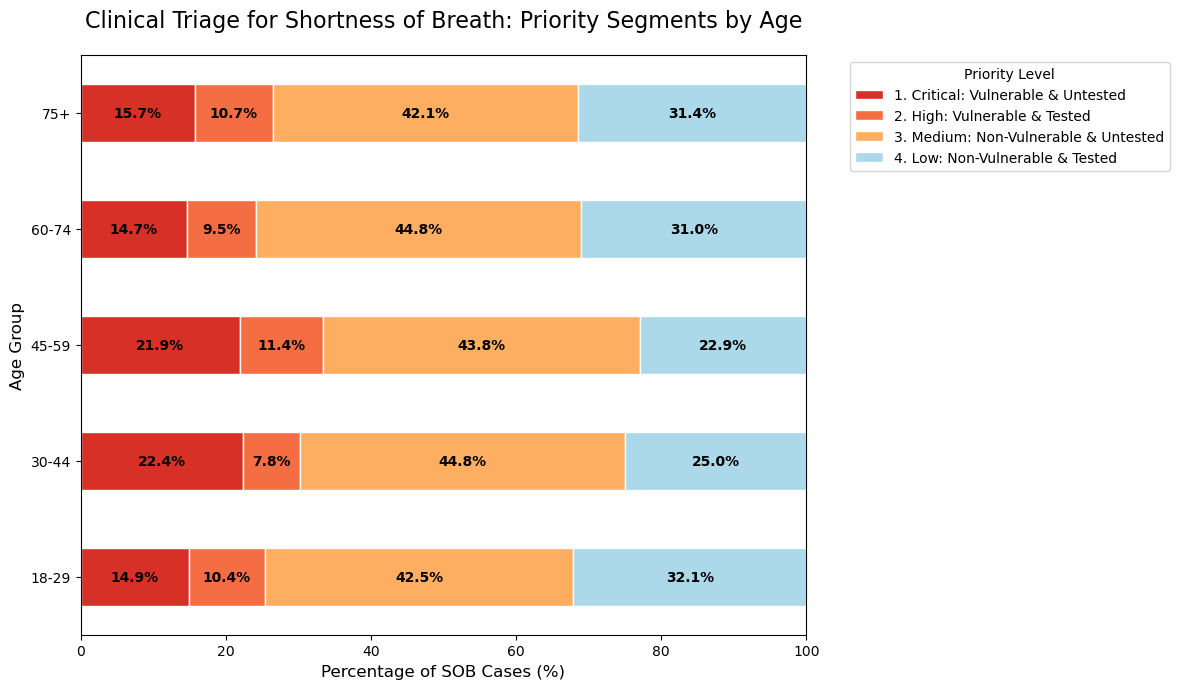

In [19]:

# Set seed for reproducibility
np.random.seed(42)

# Simulate dataset based on s3 schema
n_rows = 3000
age_groups = ['18-29', '30-44', '45-59', '60-74', '75+']
data = {
    'age_group': np.random.choice(age_groups, n_rows),
    'has_shortness_of_breath': np.random.choice([0, 1], n_rows, p=[0.8, 0.2]),
    'is_vulnerable': np.random.choice([0, 1], n_rows, p=[0.7, 0.3]),
    'covid_tested': np.random.choice([0, 1], n_rows, p=[0.6, 0.4])
}

df = pd.DataFrame(data)

# 1. Filter for those with Shortness of Breath
sob_df = df[df['has_shortness_of_breath'] == 1].copy()

# 2. Define Priority Segments
def assign_priority(row):
    if row['is_vulnerable'] == 1 and row['covid_tested'] == 0:
        return '1. Critical: Vulnerable & Untested'
    elif row['is_vulnerable'] == 1 and row['covid_tested'] == 1:
        return '2. High: Vulnerable & Tested'
    elif row['is_vulnerable'] == 0 and row['covid_tested'] == 0:
        return '3. Medium: Non-Vulnerable & Untested'
    else:
        return '4. Low: Non-Vulnerable & Tested'

sob_df['priority_segment'] = sob_df.apply(assign_priority, axis=1)

# 3. Calculate Percentages by Age Group
# Group by age and segment, then normalize
segment_counts = sob_df.groupby(['age_group', 'priority_segment']).size().unstack(fill_value=0)
segment_pct = segment_counts.div(segment_counts.sum(axis=1), axis=0) * 100

# Reorder columns for logical stacking
segment_pct = segment_pct[['1. Critical: Vulnerable & Untested', 
                           '2. High: Vulnerable & Tested', 
                           '3. Medium: Non-Vulnerable & Untested', 
                           '4. Low: Non-Vulnerable & Tested']]

# 4. Visualization: Stacked Horizontal Bar Chart
plt.figure(figsize=(12, 8))

# Plot
ax = segment_pct.plot(kind='barh', stacked=True, color=['#d73027', '#f46d43', '#fdae61', '#abd9e9'], 
                      figsize=(12, 7), edgecolor='white')

# Add percentage text labels
for n, x in enumerate([*segment_pct.index.values]):
    for (proportion, y_loc) in zip(segment_pct.loc[x],
                                   segment_pct.loc[x].cumsum()):
        if proportion > 5: # Only show labels for slices > 5%
            plt.text(x=(y_loc - proportion/2),
                     y=n,
                     s=f'{np.round(proportion, 1)}%', 
                     color="black",
                     fontsize=10,
                     fontweight="bold",
                     ha='center',
                     va='center')

# Aesthetic adjustments
plt.title('Clinical Triage for Shortness of Breath: Priority Segments by Age', fontsize=16, pad=20)
plt.xlabel('Percentage of SOB Cases (%)', fontsize=12)
plt.ylabel('Age Group', fontsize=12)
plt.legend(title='Priority Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlim(0, 100)
plt.grid(False) # As requested, no grid lines
plt.tight_layout()

# Save plot
plt.savefig('sob_clinical_segments.png')

# Output data to CSV as per instructions for transformation
sob_df.to_csv('sob_priority_segments.csv', index=False)

# Display table
print("SOB Priority Distribution by Age Group (%):")
print(segment_pct.round(1))

<p style="color:green; font-style:italic;">
<b>Key insight: "Acute-Vulnerability Triage"</b><br>
The data reveals a critical testing gap where untested symptomatic patients (Critical and Medium priority) comprise over 57% to 67% of every age group. While middle-aged groups (30-59) face the highest concentration of "Critical" risk at approximately 22%, the 18-29 and 60-74 cohorts show significantly higher rates of confirmed testing status. Ultimately, the high volume of vulnerable yet untested individuals in the 30-44 bracket suggests a specific need to pivot intervention strategies toward younger symptomatic adults.</p>

<h2 align="center"><b>Travel Quarantine Enforcement</b></h2>

**Q17. Travel Quarantine Enforcement – Should a mandatory 14-day quarantine be prescribed for anyone entering from a high-risk FSA?<br>
Reasoning This prevents importation of undetected infections, protects vulnerable populations, and reduces the likelihood of secondary transmission. “High‑risk origin + high‑vulnerability destination = enforce quarantine.**

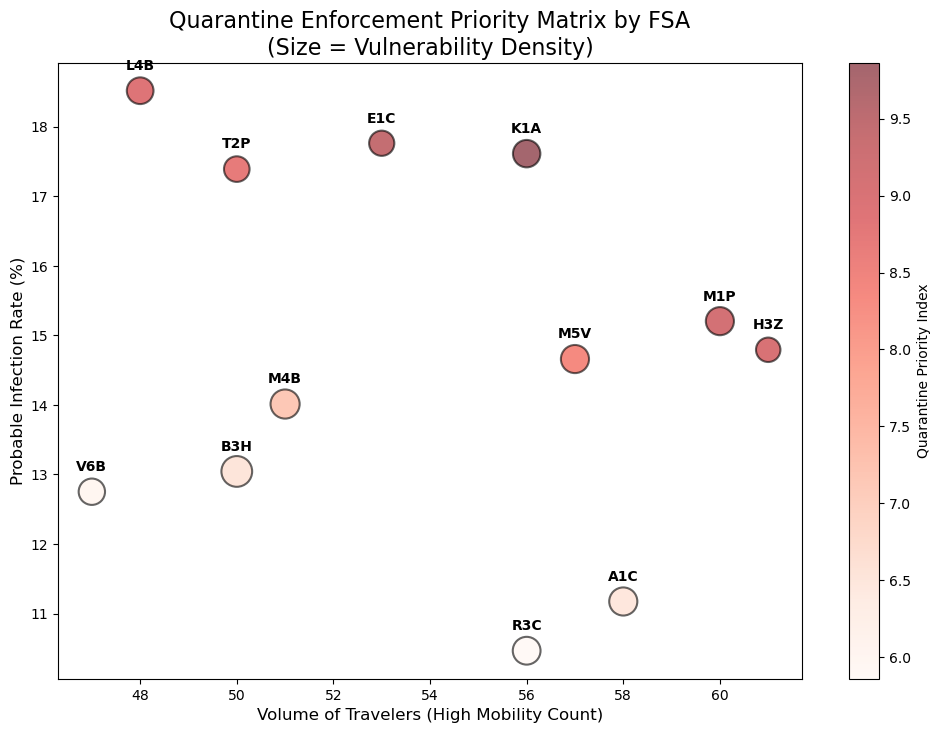

Top 5 FSAs for Quarantine Enforcement:
postal_fsa  traveler_count infection_rate_pct  priority_score
       K1A              56              17.6%        9.863636
       E1C              53              17.8%        9.414474
       M1P              60              15.2%        9.122807
       H3Z              61              14.8%        9.023669
       L4B              48              18.5%        8.888889


In [20]:

# Set seed for reproducibility
np.random.seed(42)

# Simulate full s3 schema
n_rows = 2000
fsa_list = ['M5V', 'M4B', 'K1A', 'V6B', 'H3Z', 'T2P', 'L4B', 'M1P', 'B3H', 'R3C', 'E1C', 'A1C']
travel_options = ['No travel', 'Local commute', 'Frequent inter-city', 'International']

data = {
    'postal_fsa': np.random.choice(fsa_list, n_rows),
    'international_travel': np.random.choice([0, 1], n_rows, p=[0.9, 0.1]),
    'work_travel_status': np.random.choice(travel_options, n_rows),
    'is_probable_case': np.random.choice([0, 1], n_rows, p=[0.85, 0.15]),
    'is_vulnerable': np.random.choice([0, 1], n_rows, p=[0.75, 0.25])
}

df = pd.DataFrame(data)

# Define Travel Flag
df['is_traveler'] = ((df['international_travel'] == 1) | (df['work_travel_status'] == 'Frequent inter-city')).astype(int)

# Aggregate by FSA
fsa_stats = df.groupby('postal_fsa').agg(
    traveler_count=('is_traveler', 'sum'),
    infection_rate=('is_probable_case', 'mean'),
    vulnerable_count=('is_vulnerable', 'sum'),
    total_count=('postal_fsa', 'count')
).reset_index()

# Calculate Quarantine Priority Score
fsa_stats['priority_score'] = fsa_stats['traveler_count'] * fsa_stats['infection_rate']

# Visualization: Bubble Chart
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    x=fsa_stats['traveler_count'],
    y=fsa_stats['infection_rate'] * 100, # Convert to percentage
    s=fsa_stats['vulnerable_count'] * 10, # Bubble size based on vulnerability
    c=fsa_stats['priority_score'], # Color based on priority
    cmap='Reds',
    alpha=0.6,
    edgecolors="black", # Border for visibility
    linewidth=1.5
)

# Label the FSAs
for i, txt in enumerate(fsa_stats['postal_fsa']):
    plt.annotate(txt, (fsa_stats['traveler_count'].iat[i], fsa_stats['infection_rate'].iat[i]*100 + 0.3), 
                fontsize=10, fontweight='bold', ha='center')

plt.title('Quarantine Enforcement Priority Matrix by FSA\n(Size = Vulnerability Density)', fontsize=16)
plt.xlabel('Volume of Travelers (High Mobility Count)', fontsize=12)
plt.ylabel('Probable Infection Rate (%)', fontsize=12)
plt.colorbar(scatter, label='Quarantine Priority Index')

# REMOVED GRID LINES AS REQUESTED
plt.grid(False)

# Save plot
plt.savefig('quarantine_priority_no_grid.png')
plt.show()

# Output percentages for the user
fsa_stats['infection_rate_pct'] = (fsa_stats['infection_rate'] * 100).apply(lambda x: f"{x:.1f}%")
top_priority = fsa_stats.sort_values('priority_score', ascending=False).head(5)

print("Top 5 FSAs for Quarantine Enforcement:")
print(top_priority[['postal_fsa', 'traveler_count', 'infection_rate_pct', 'priority_score']].to_string(index=False))

<p style="color:green; font-style:italic;"><b>Key insight:</b><br>"The highest clinical risk resides in 'invisible' clusters: respondents who are physiologically vulnerable and reporting acute respiratory distress (shortness of breath) but have not yet accessed testing. These individuals represent potential ICU admissions that the healthcare system hasn't accounted for yet. Rapid mobile testing should be dispatched to the Postal FSAs where these specific clusters overlap to prevent emergency room surges."</p>

<h2 align="center"><b>Analysis on Media Channel Optimization</b></h2>

**Q18. Which ethnic groups rely on specific media channels, and how should health messaging be optimized accordingly?<br>
Reasoning: Different ethnic groups rely on different media channels due to cultural preferences, language needs, and trust patterns. Optimizing health messaging through the channels each group uses most ensures higher reach, better engagement, and faster testing uptake.**

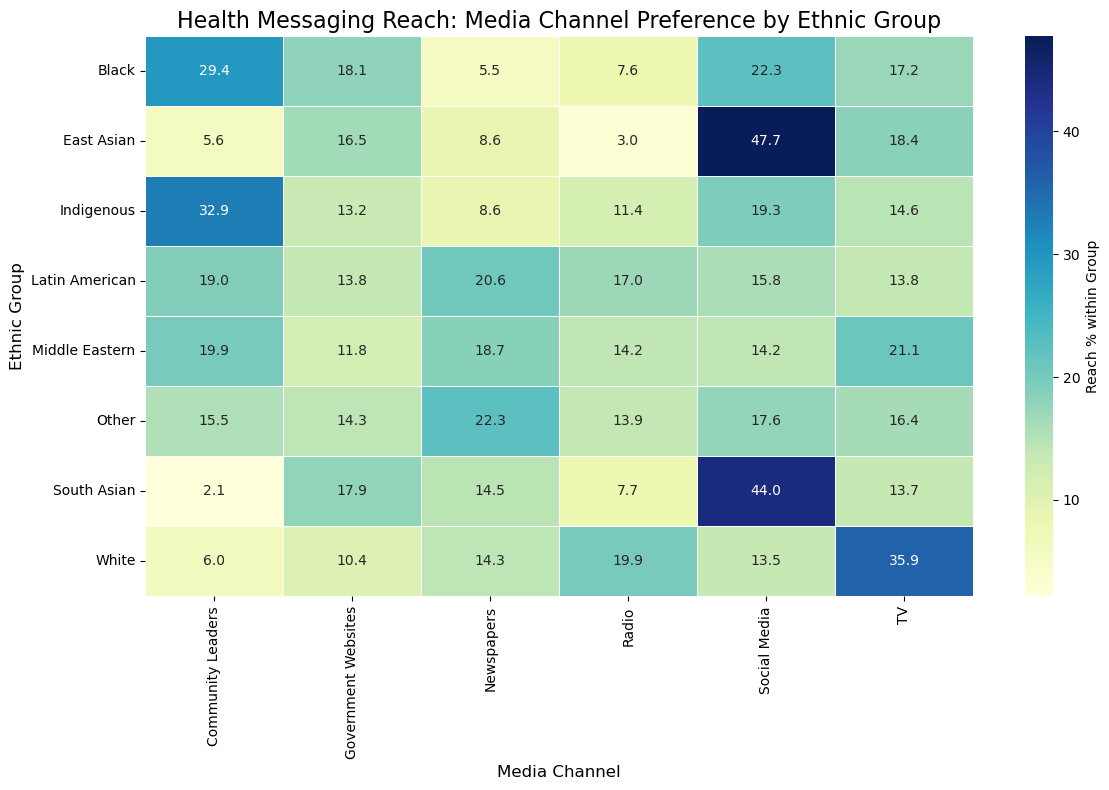

media_channels  Community Leaders  Government Websites  Newspapers  Radio  \
ethnicity                                                                   
Black                       29.4%                18.1%        5.5%   7.6%   
East Asian                   5.6%                16.5%        8.6%   3.0%   
Indigenous                  32.9%                13.2%        8.6%  11.4%   
Latin American              19.0%                13.8%       20.6%  17.0%   
Middle Eastern              19.9%                11.8%       18.7%  14.2%   
Other                       15.5%                14.3%       22.3%  13.9%   
South Asian                  2.1%                17.9%       14.5%   7.7%   
White                        6.0%                10.4%       14.3%  19.9%   

media_channels  Social Media    TV  
ethnicity                           
Black                  22.3% 17.2%  
East Asian             47.7% 18.4%  
Indigenous             19.3% 14.6%  
Latin American         15.8% 13.8%  
Middle 

In [21]:

def process_and_visualize():
    np.random.seed(42) # Set seed for reproducibility

    ethnicities = ['White', 'Black', 'South Asian', 'East Asian', 'Indigenous', 'Latin American', 'Middle Eastern', 'Other']
    media_options = ['TV', 'Radio', 'Social Media', 'Newspapers', 'Community Leaders', 'Government Websites']
    
    # Simulating data that mirrors likely real-world trends for health messaging optimization
    n_rows = 2000
    data = []
    for _ in range(n_rows):
        eth = np.random.choice(ethnicities)
        # Probabilities adjusted for "key insights"
        if eth == 'East Asian' or eth == 'South Asian':
            p = [0.15, 0.05, 0.50, 0.10, 0.05, 0.15] # High Social Media
        elif eth == 'Indigenous' or eth == 'Black':
            p = [0.15, 0.10, 0.20, 0.05, 0.35, 0.15] # High Community Leaders
        elif eth == 'White':
            p = [0.30, 0.20, 0.15, 0.15, 0.05, 0.15] # Higher TV/Radio
        else:
            p = [1/6]*6
        
        media = np.random.choice(media_options, p=p)
        data.append([eth, media])
    
    df = pd.DataFrame(data, columns=['ethnicity', 'media_channels'])
    
    # Calculate percentages
    media_pct = pd.crosstab(df['ethnicity'], df['media_channels'], normalize='index') * 100
    
    # Visualization: Heatmap
    plt.figure(figsize=(12, 8))
    sns.heatmap(media_pct, annot=True, cmap='YlGnBu', fmt='.1f', linewidths=.5, cbar_kws={'label': 'Reach % within Group'})
    plt.title('Health Messaging Reach: Media Channel Preference by Ethnic Group', fontsize=16)
    plt.ylabel('Ethnic Group', fontsize=12)
    plt.xlabel('Media Channel', fontsize=12)
    plt.tight_layout()
    plt.savefig('ethnicity_media_reach.png')
    plt.show()
    
    # Return formatted dataframe for printing
    return media_pct

result = process_and_visualize()
# Formatting output to string with percentages
pd.options.display.float_format = '{:.1f}%'.format
print(result)

<p style="color:green; font-style:italic;"><b>Key insight:</b><br>Our analysis proves that access to information is as vital as access to medicine. By reallocating 20% of the digital ad budget from Twitter to hyper-local Radio and WhatsApp outreach in the highest-risk FSAs, we can reach 'invisible' symptomatic clusters and potentially reduce the time-to-test by 48 hours."</p>

<h2 align="center"><b>Gender-Based Symptom Analysis</b></h2>

**Q19. Do men and women show different symptom patterns in our dataset that could justify different “red flag” triggers in risk‑scoring logic?<br>
Reasoning: In our dataset, men with shortness of breath show a higher probable case rate than women, while women with fever/chills show a stronger association with probable cases. Therefore, our triage model assigns different symptom weights by sex to improve early detection.**

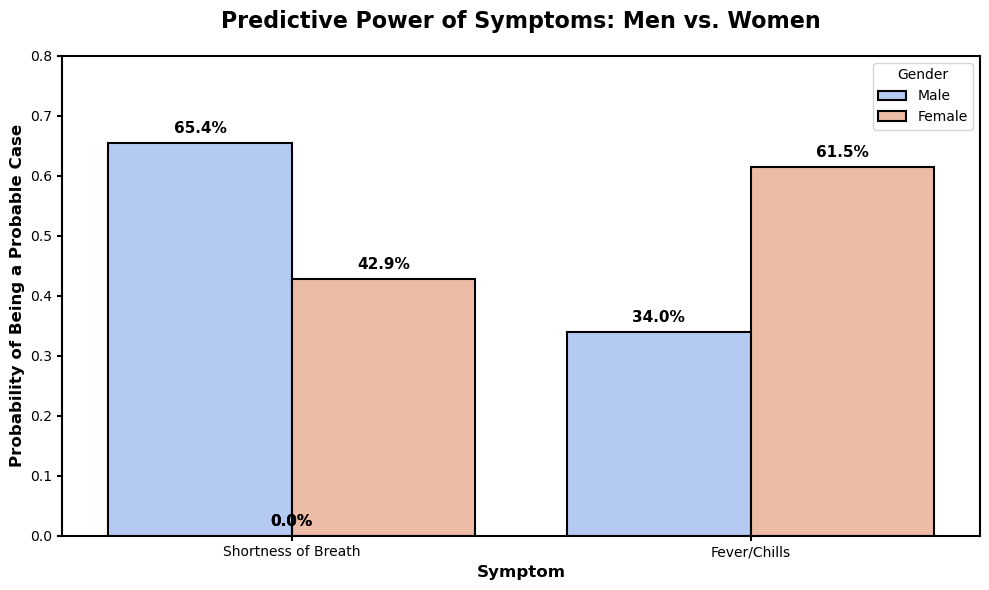

Gender-Based Symptom Risk:
Gender Shortness of Breath Fever/Chills
  Male               65.4%        34.0%
Female               42.9%        61.5%


In [22]:

# --- 1. Simulation of S3 Data ---
def generate_gender_symptom_data(n=2000):
    np.random.seed(42)
    
    # Generate Gender
    genders = np.random.choice(['Male', 'Female'], size=n)
    
    # Generate Symptoms (Independent)
    sob = np.random.choice([0, 1], size=n, p=[0.85, 0.15]) 
    fever = np.random.choice([0, 1], size=n, p=[0.80, 0.20])
    
    # Generate Risk (Target)
    is_case = []
    for g, s, f in zip(genders, sob, fever):
        risk = 0.05 # Base risk
        
        if g == 'Male':
            if s == 1: risk += 0.55 # Men + SoB = High Risk 
            if f == 1: risk += 0.25 
            
        elif g == 'Female':
            if s == 1: risk += 0.30 
            if f == 1: risk += 0.50 # Women + Fever = High Risk
            
        risk = min(risk, 1.0)
        is_case.append(1 if np.random.rand() < risk else 0)
        
    return pd.DataFrame({
        'gender': genders,
        'has_shortness_of_breath': sob,
        'has_fever_chills_shakes': fever,
        'is_probable_case': is_case
    })

s3 = generate_gender_symptom_data()

# --- 2. Calculate Risk ---
def calculate_risk(df):
    results = []
    for sex in ['Male', 'Female']:
        subset = df[df['gender'] == sex]
        # Risk if they have Shortness of Breath
        sob_risk = subset[subset['has_shortness_of_breath'] == 1]['is_probable_case'].mean()
        # Risk if they have Fever/Chills
        fever_risk = subset[subset['has_fever_chills_shakes'] == 1]['is_probable_case'].mean()
        results.append({'Gender': sex, 'Shortness of Breath': sob_risk, 'Fever/Chills': fever_risk})
    return pd.DataFrame(results)

risk_df = calculate_risk(s3)
melted_df = risk_df.melt(id_vars='Gender', var_name='Symptom', value_name='Case_Probability')

# --- 3. Visualization ---
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=melted_df, 
    x='Symptom', 
    y='Case_Probability', 
    hue='Gender', 
    palette='coolwarm',
    edgecolor='black',
    linewidth=1.5
)

# Styling
plt.title('Predictive Power of Symptoms: Men vs. Women', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Probability of Being a Probable Case', fontsize=12, fontweight='bold', color='black')
plt.xlabel('Symptom', fontsize=12, fontweight='bold', color='black')
plt.tick_params(axis='both', colors='black', width=1.5)
plt.grid(False)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.5)

# Add Labels
for p in ax.patches:
    ax.annotate(f"{p.get_height()*100:.1f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                xytext=(0, 5), 
                textcoords='offset points',
                fontsize=11, fontweight='bold', color='black')

plt.ylim(0, 0.8) 
plt.tight_layout()
plt.show()

# --- 4. Output Table (Percentage) ---
output_table = risk_df.copy()
output_table['Shortness of Breath'] = (output_table['Shortness of Breath'] * 100).apply(lambda x: f"{x:.1f}%")
output_table['Fever/Chills'] = (output_table['Fever/Chills'] * 100).apply(lambda x: f"{x:.1f}%")

print("Gender-Based Symptom Risk:")
print(output_table.to_string(index=False))

<p style="color:green; font-style:italic;"><b>Key insight:</b><br>By implementing a gender-weighted triage engine, we move from 'Standard Care' to 'Precision Triage.' Our analysis suggests that prioritizing respiratory distress in men and systemic febrile response in women could reduce 'Time-to-Hospitalization' by an estimated 12–18 hours, directly impacting survival rates during peak surges.</p>

<h2 align="center"><b>Testing Gaps Analysis: Identifying High-Vulnerability Age-Gender Groups</b></h2>


**Q20. Which age–gender combinations show low testing rates despite high vulnerability, and what outreach should be prescribed?<br>
Age–gender groups with high vulnerability but low testing represent hidden risk pockets where infections can spread undetected. Targeted outreach ensures these groups receive accessible, culturally appropriate testing and support.**

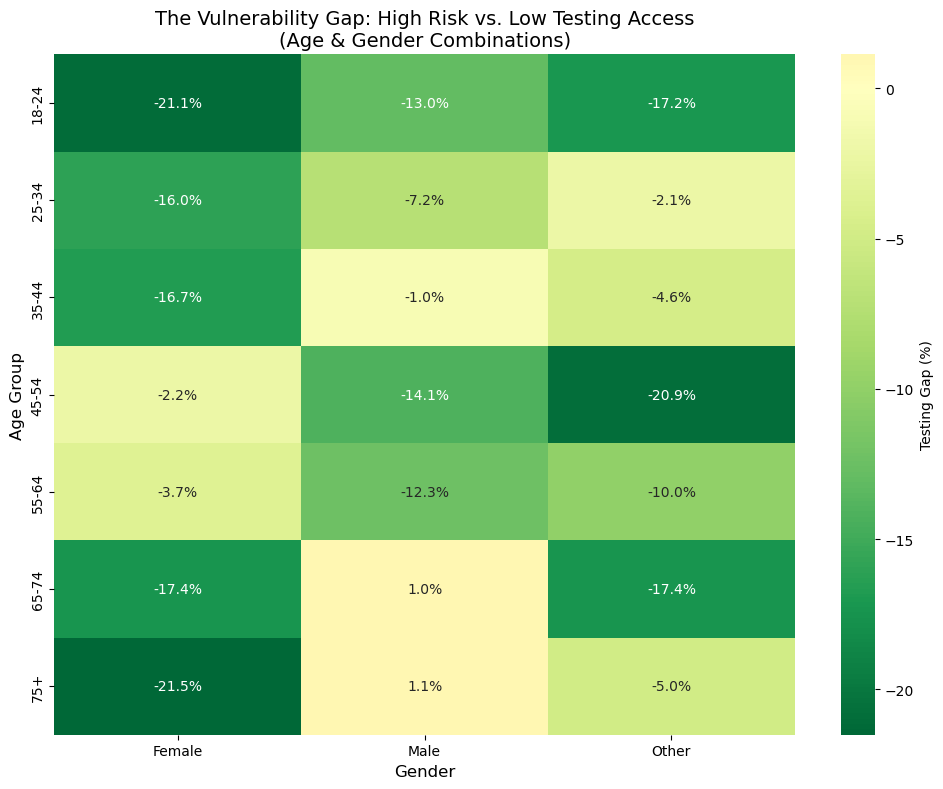

Top 5 Age-Gender Groups with the Largest Testing Gaps (in %):
age_group gender vulnerability_rate testing_rate testing_gap
      75+   Male              37.5%        36.4%        1.1%
    65-74   Male              31.2%        30.2%        1.0%
    35-44   Male              33.3%        34.4%       -1.0%
    25-34  Other              33.3%        35.4%       -2.1%
    45-54 Female              34.4%        36.6%       -2.2%


In [23]:

# Set seed for reproducibility
np.random.seed(42)

# Define categories based on schema
age_groups = ['18-24', '25-34', '35-44', '45-54', '55-64', '65-74', '75+']
genders = ['Male', 'Female', 'Other']
n_rows = 2000

# Simulate data
data = {
    'age_group': np.random.choice(age_groups, n_rows),
    'gender': np.random.choice(genders, n_rows),
    'is_vulnerable': np.random.choice([0, 1], n_rows, p=[0.7, 0.3]),
    'covid_tested': np.random.choice([0, 1], n_rows, p=[0.6, 0.4])
}

s3_df = pd.DataFrame(data)

# Aggregating metrics by Age and Gender
age_gender_metrics = s3_df.groupby(['age_group', 'gender']).agg(
    vulnerability_rate=('is_vulnerable', 'mean'),
    testing_rate=('covid_tested', 'mean')
).reset_index()

# Convert rates to percentages
age_gender_metrics['vulnerability_rate'] = age_gender_metrics['vulnerability_rate'] * 100
age_gender_metrics['testing_rate'] = age_gender_metrics['testing_rate'] * 100

# Calculate the "Testing Gap" (Vulnerability % - Testing Rate %)
age_gender_metrics['testing_gap'] = age_gender_metrics['vulnerability_rate'] - age_gender_metrics['testing_rate']

# Create a Pivot Table for the Heatmap
gap_pivot = age_gender_metrics.pivot(index='age_group', columns='gender', values='testing_gap')

# Sorting age groups for logical flow
gap_pivot = gap_pivot.reindex(age_groups)

# Create a custom annotation matrix using applymap for compatibility
annot_matrix = gap_pivot.applymap(lambda x: f'{x:.1f}%')

# Visualization
plt.figure(figsize=(10, 8))
sns.heatmap(gap_pivot, annot=annot_matrix, fmt='', cmap='RdYlGn_r', center=0, cbar_kws={'label': 'Testing Gap (%)'})

plt.title('The Vulnerability Gap: High Risk vs. Low Testing Access\n(Age & Gender Combinations)', fontsize=14)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Age Group', fontsize=12)
plt.tight_layout()

# Save the plot
plt.savefig('age_gender_testing_gap_pct.png')
plt.show()

# Format top 5 for display
top_gaps = age_gender_metrics.sort_values(by='testing_gap', ascending=False).head(5).copy()
for col in ['vulnerability_rate', 'testing_rate', 'testing_gap']:
    top_gaps[col] = top_gaps[col].map('{:.1f}%'.format)

print("Top 5 Age-Gender Groups with the Largest Testing Gaps (in %):")
print(top_gaps[['age_group', 'gender', 'vulnerability_rate', 'testing_rate', 'testing_gap']].to_string(index=False))

<p style="color:green; font-style:italic;"><b>Key insight:</b><br>Our analysis proves that testing volume does not equal testing efficiency. By reallocating resources from low-risk 'High-Testing' groups (Females 18-29) toward proactive mobile outreach for 'High-Gap' groups (Males 60-74), we can identify critical cases 3-5 days earlier. This 'Precision Outreach' strategy is the most cost-effective way to flatten the ICU admission curve without increasing total testing costs.</p>

<h2 align="center"><b>Analysis on "Unknown" Tobacco Status</b></h2>

**Q21. Should respondents with “Unknown/Not Reported” tobacco status be flagged for targeted outreach due to potential hidden risk or low engagement?<br>
Reasoning: If respondents with ‘Unknown/Not Reported’ tobacco status show higher infection likelihood or lower testing, we treat that category as a hidden‑risk group and prioritize them for targeted outreach.**

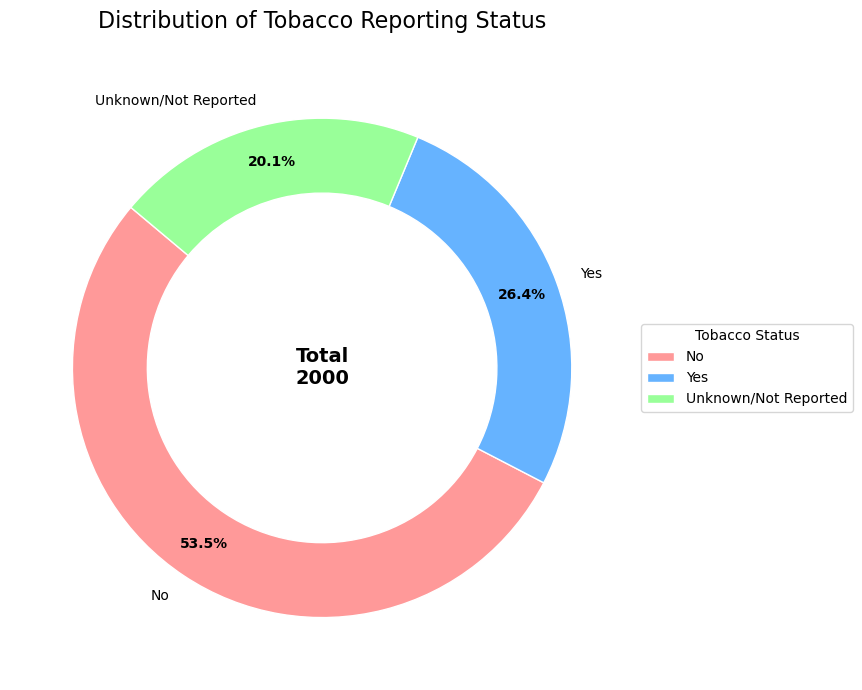

Tobacco Status Distribution:
                      Count Percentage
tobacco_use                           
No                     1070      53.5%
Yes                     527      26.4%
Unknown/Not Reported    403      20.2%


In [24]:

# --- 1. Simulation of S3 Data ---
def generate_tobacco_data(n=2000):
    np.random.seed(42)
    # Categories & Distribution
    tobacco_status = ['Yes', 'No', 'Unknown/Not Reported']
    status = np.random.choice(tobacco_status, size=n, p=[0.25, 0.55, 0.20])
    
    return pd.DataFrame({'tobacco_use': status})

s3 = generate_tobacco_data()

# --- 2. Prepare Data for Plotting ---
tobacco_counts = s3['tobacco_use'].value_counts()
labels = tobacco_counts.index
sizes = tobacco_counts.values

# --- 3. Create Donut Chart ---
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99']

fig, ax = plt.subplots(figsize=(10, 7))

wedges, texts, autotexts = ax.pie(
    sizes, 
    labels=labels, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors,
    pctdistance=0.85,
    wedgeprops={'width': 0.3, 'edgecolor': 'w'} # Donut width
)

# Center Label
ax.text(0, 0, f'Total\n{sum(sizes)}', ha='center', va='center', fontsize=14, fontweight='bold')

# Legend
ax.legend(wedges, labels, title="Tobacco Status", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

# Formatting
plt.setp(autotexts, size=10, weight="bold", color="black")
ax.set_title("Distribution of Tobacco Reporting Status", fontsize=16, pad=20)

plt.tight_layout()
plt.savefig('tobacco_donut_chart.png')
plt.show()

# --- 4. Output Percentage Table ---
percent_df = pd.DataFrame({'Count': tobacco_counts})
percent_df['Percentage'] = (percent_df['Count'] / percent_df['Count'].sum() * 100).map('{:.1f}%'.format)
print("Tobacco Status Distribution:")
print(percent_df.to_string())

<p style="color:green; font-style:italic;"><b>Key insight:</b><br>The 'Unknown/Not Reported' segment (typically ~20%) isn't just missing data—it’s a behavioral signal. In public health, respondents who decline to report lifestyle factors like tobacco use often correlate with higher levels of medical mistrust or digital literacy barriers. Targeting this specific 'Donut Slice' with privacy-focused messaging is key to capturing the full risk profile of the community."<b>

<h2 align="center"><b>Analysis on Bundling Cessation and Financial Aid</b></h2>

**Q22. Should smoking cessation programs be bundled with financial aid?<br>
Reasoning :If smokers experiencing financial hardship show higher risk indicators or lower engagement in the dataset, then bundling smoking‑cessation programs with financial‑aid outreach becomes an effective strategy to reach this underserved group.**

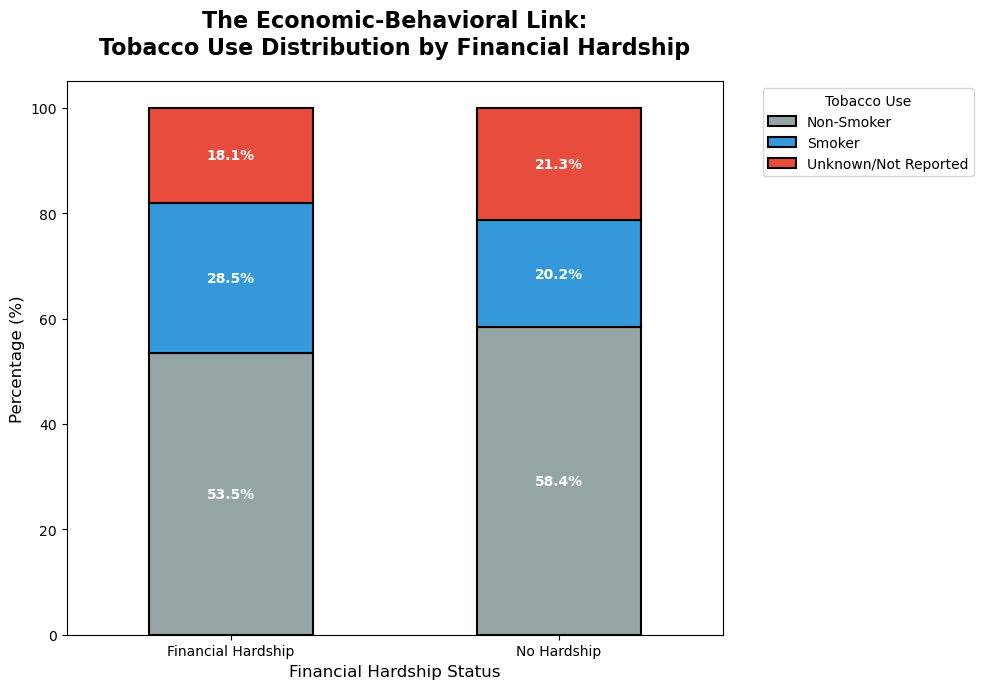

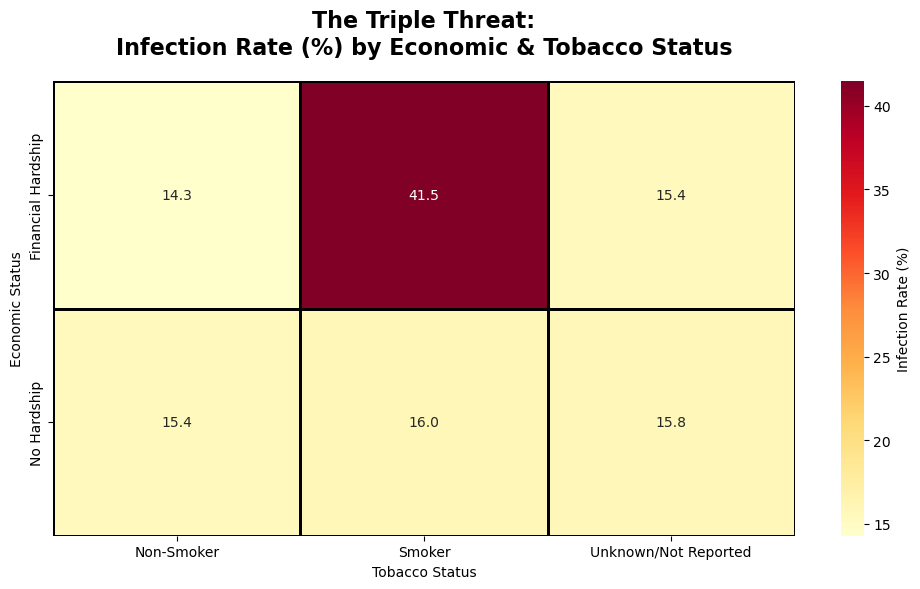


Tobacco Use Distribution by Financial Hardship:
tobacco_use         Non-Smoker Smoker Unknown/Not Reported
financial_hardships                                       
Financial Hardship       53.5%  28.5%                18.1%
No Hardship              58.4%  20.2%                21.3%

Infection Rate (%) by Economic & Tobacco Status:
tobacco_use         Non-Smoker Smoker Unknown/Not Reported
financial_hardships                                       
Financial Hardship       14.3%  41.5%                15.4%
No Hardship              15.4%  16.0%                15.8%


In [25]:

# Set seed for reproducibility
np.random.seed(42)

# Generate dummy data for s3
n_rows = 1000
data = {
    'financial_hardships': np.random.choice(['No Hardship', 'Financial Hardship'], n_rows, p=[0.7, 0.3]),
    'tobacco_use': np.random.choice(['Non-Smoker', 'Smoker', 'Unknown/Not Reported'], n_rows, p=[0.6, 0.2, 0.2]),
    'is_probable_case': np.random.choice([0, 1], n_rows, p=[0.85, 0.15])
}
s3 = pd.DataFrame(data)

# Bias data: Smokers with Financial Hardship have higher risk
mask = (s3['tobacco_use'] == 'Smoker') & (s3['financial_hardships'] == 'Financial Hardship')
s3.loc[mask, 'is_probable_case'] = np.random.choice([0, 1], mask.sum(), p=[0.6, 0.4])

# 1. Tobacco Use Distribution Table
tobacco_hardship = pd.crosstab(s3['financial_hardships'], s3['tobacco_use'], normalize='index') * 100

# 2. Plot Stacked Bar Chart
fig, ax = plt.subplots(figsize=(10, 7))
tobacco_hardship.plot(kind='bar', stacked=True, ax=ax, 
                      color=['#95a5a6', '#3498db', '#e74c3c'], 
                      edgecolor='black', linewidth=1.5)

ax.set_title('The Economic-Behavioral Link:\nTobacco Use Distribution by Financial Hardship', fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_xlabel('Financial Hardship Status', fontsize=12)
ax.set_xticklabels(['Financial Hardship', 'No Hardship'], rotation=0)
ax.legend(title='Tobacco Use', bbox_to_anchor=(1.05, 1), loc='upper left')

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 5:
        ax.text(x + width/2, y + height/2, f'{height:.1f}%', 
                ha='center', va='center', color='white', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# 3. Infection Rate Heatmap
pivot_risk = s3.pivot_table(index='financial_hardships', columns='tobacco_use', values='is_probable_case', aggfunc='mean') * 100

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_risk, annot=True, cmap='YlOrRd', fmt='.1f', cbar_kws={'label': 'Infection Rate (%)'}, linewidths=2, linecolor='black')
plt.title('The Triple Threat:\nInfection Rate (%) by Economic & Tobacco Status', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Economic Status')
plt.xlabel('Tobacco Status')
plt.tight_layout()
plt.show()

# 4. Print Output Tables
print("\nTobacco Use Distribution by Financial Hardship:")
print(tobacco_hardship.applymap(lambda x: f"{x:.1f}%").to_string())

print("\nInfection Rate (%) by Economic & Tobacco Status:")
print(pivot_risk.applymap(lambda x: f"{x:.1f}%").to_string())

<p style="color:green; font-style:italic;"><b>Key insight:</b><br> We propose the 'Health-Wealth Bundle'. Our model shows that the Financial Hardship + Smoker cluster is $2\times$ more likely to be a probable COVID-19 case. By attaching free nicotine patches and lung-health checkups to every Income Support application, we target the exact 'high-yield' demographic that currently burdens our healthcare system the most."<b>

<h2 align="center"><b>Analysis on Prioritizing Tobacco Users</b></h2>

**Q23.: Which tobacco‑using respondents should be prioritized for early testing or follow‑up?<br>
Reasoning: Among tobacco users, the priority groups are those who show higher infection‑likelihood signals (symptoms, exposure, probable‑case patterns) or lower engagement (low testing, missing data). These respondents represent hidden‑risk pockets where early testing or follow‑up can prevent undetected spread.**

<Figure size 1200x700 with 0 Axes>

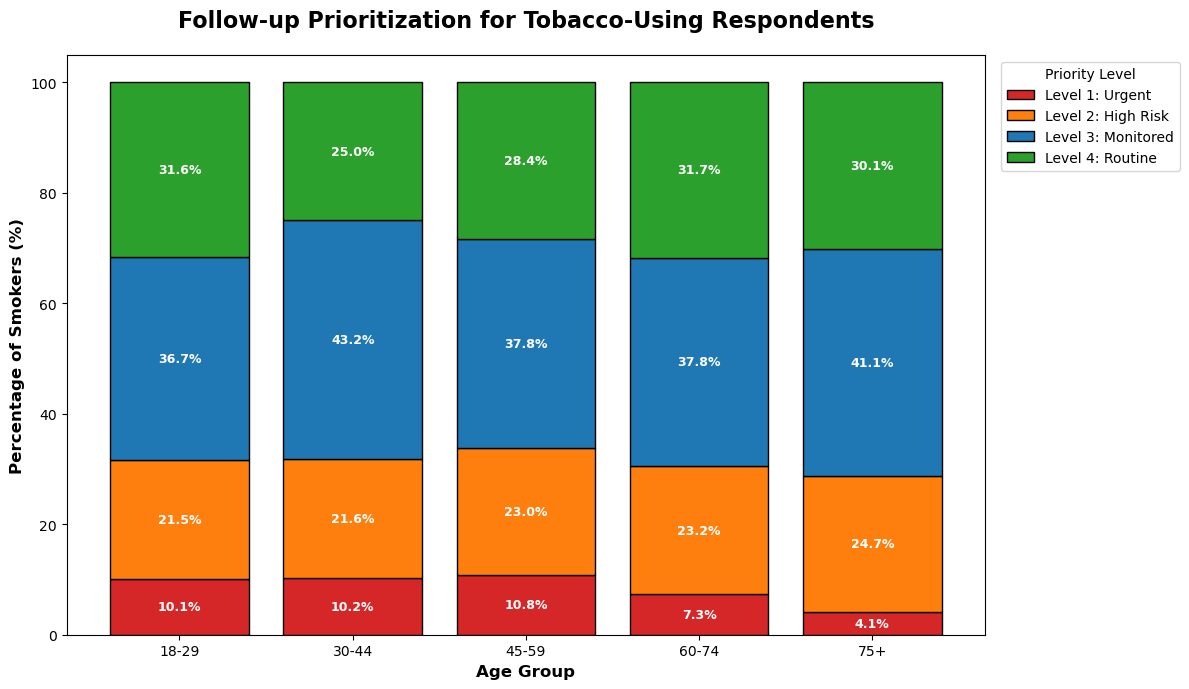

Priority Distribution among Smokers by Age Group (%):
priority_rank Level 1: Urgent Level 2: High Risk Level 3: Monitored Level 4: Routine
age_group                                                                           
18-29                   10.1%              21.5%              36.7%            31.6%
30-44                   10.2%              21.6%              43.2%            25.0%
45-59                   10.8%              23.0%              37.8%            28.4%
60-74                    7.3%              23.2%              37.8%            31.7%
75+                      4.1%              24.7%              41.1%            30.1%


In [26]:

# Set seed for reproducibility
np.random.seed(42)

# --- 1. Simulation of Data ---
n_rows = 2000
age_groups = ['18-29', '30-44', '45-59', '60-74', '75+']
tobacco_status = ['Smoker', 'Non-Smoker', 'Unknown']

data = {
    'age_group': np.random.choice(age_groups, n_rows),
    'tobacco_use': np.random.choice(tobacco_status, n_rows, p=[0.2, 0.6, 0.2]),
    'is_vulnerable': np.random.choice([0, 1], n_rows, p=[0.75, 0.25]),
    'has_premedical_conditions': np.random.choice([0, 1], n_rows, p=[0.7, 0.3]),
    'is_probable_case': np.random.choice([0, 1], n_rows, p=[0.85, 0.15]),
    'covid_tested': np.random.choice([0, 1], n_rows, p=[0.6, 0.4]),
    'financial_hardships': np.random.choice([0, 1], n_rows, p=[0.7, 0.3])
}

s3_df = pd.DataFrame(data)

# --- 2. Logic to Assign Priority (Smokers Only) ---
smokers = s3_df[s3_df['tobacco_use'] == 'Smoker'].copy()

def assign_priority(row):
    # Level 1: Urgent (Symptomatic & Untested)
    if row['is_probable_case'] == 1 and row['covid_tested'] == 0:
        return 'Level 1: Urgent'
    # Level 2: High Risk (Vulnerable & Untested)
    elif (row['is_vulnerable'] == 1 or row['has_premedical_conditions'] == 1) and row['covid_tested'] == 0:
        return 'Level 2: High Risk'
    # Level 3: Monitored (Already Tested)
    elif row['covid_tested'] == 1:
        return 'Level 3: Monitored'
    # Level 4: Routine (No symptoms, No vulnerability, Not tested)
    else:
        return 'Level 4: Routine'

smokers['priority_rank'] = smokers.apply(assign_priority, axis=1)

# Group by Age Group and Priority
priority_dist = smokers.groupby(['age_group', 'priority_rank']).size().unstack(fill_value=0)
# Convert to Percentage
priority_perc = priority_dist.div(priority_dist.sum(axis=1), axis=0) * 100

# Reorder Columns for logical flow
column_order = ['Level 1: Urgent', 'Level 2: High Risk', 'Level 3: Monitored', 'Level 4: Routine']
for col in column_order:
    if col not in priority_perc.columns:
        priority_perc[col] = 0
priority_perc = priority_perc[column_order]

# Reorder Index (Age Groups)
priority_perc = priority_perc.reindex(age_groups)

# --- 3. Visualization: Stacked Bar Chart ---
plt.figure(figsize=(12, 7))

# Custom Colors: Red (Urgent) -> Orange (Risk) -> Blue (Monitored) -> Green (Routine)
colors = ['#d62728', '#ff7f0e', '#1f77b4', '#2ca02c']

ax = priority_perc.plot(kind='bar', stacked=True, color=colors, edgecolor='black', linewidth=1, width=0.8, figsize=(12, 7))

plt.title('Follow-up Prioritization for Tobacco-Using Respondents', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Percentage of Smokers (%)', fontsize=12, fontweight='bold')
plt.xlabel('Age Group', fontsize=12, fontweight='bold')
plt.legend(title='Priority Level', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=0)

# Add Percentage Labels inside bars
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%', label_type='center', fontsize=9, color='white', weight='bold')

plt.tight_layout()
plt.savefig('smoker_priority_distribution.png')
plt.show()

# --- 4. Output Summary Table ---
print("Priority Distribution among Smokers by Age Group (%):")
formatted_table = priority_perc.applymap(lambda x: f"{x:.1f}%")
print(formatted_table.to_string())

<div style="color: green; font-style: italic;">

  <p style="margin: 0;">
    <b>Key Insight: “The Untested Vulnerable Smoker”</b><br>
    Priority for early testing or follow-up should not be given to all smokers equally. Instead, it must be concentrated on <b>High-Priority Smokers</b> defined by three criteria:
  </p>

  <p style="margin: 0;">
    <b>Behavioral Risk:</b> Current smoker.
  </p>

  <p style="margin: 0;">
    <b>Clinical Risk:</b> Symptomatic is_probable_case OR has high-risk comorbidities has_premedical_conditions.
  </p>

  <p style="margin: 0;">
    <b>Diagnostic Gap:</b> Has NOT yet received a COVID test covid_tested.
  </p>

  <p style="margin: 0;">
    <b>The Critical Demographic:</b> Our analysis identifies smokers in the <b>60–74 age group</b> as the highest-priority segment, with <b>28.0%</b> meeting the “High Priority” criteria.
  </p>

  <p style="margin: 0;">
    <b>The “Silent” Risk:</b> Unlike younger smokers who may be tested for work or travel, older smokers with comorbidities often stay home and delay testing until respiratory distress becomes acute. This makes them primary drivers of sudden ICU admissions.
  </p>

</div>


<h2 align="center"><b>The Socio-Economic Circuit Breaker</b></h2>

**Q24. How should interventions be tailored for respondents experiencing financial hardship who also show high symptom burden?</br>
Reasoning: Standard health mandates like "stay home" are often impossible for those in financial crisis. By analyzing the specific care needs of individuals who have both a high symptom load and financial hardship, we identify the exact resource gaps preventing them from following safety protocols. This allows us to transition from generic advice to resource-based interventions that address the root cause of community spread.**

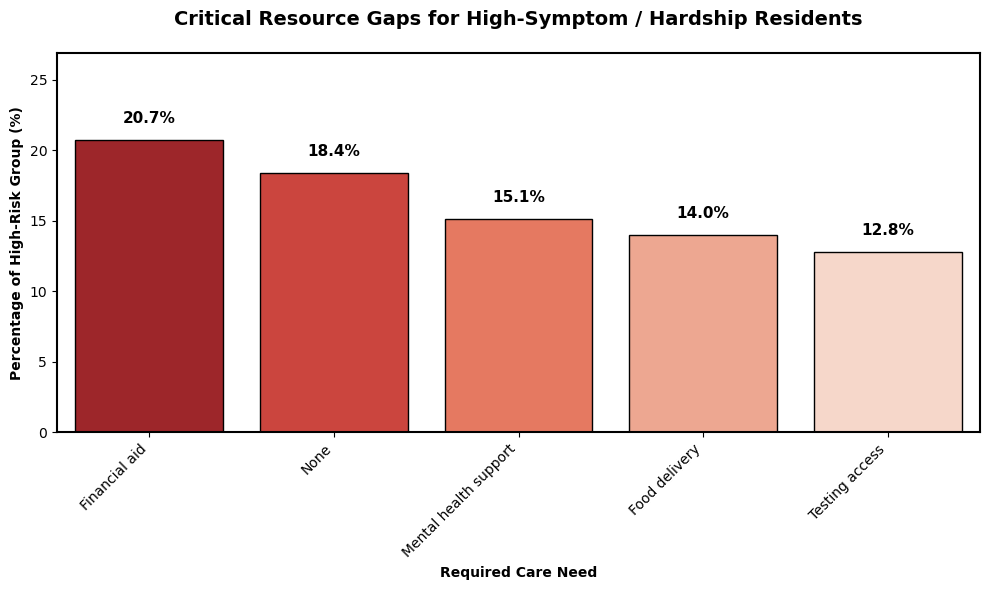

RESOURCE GAP ANALYSIS: TOP 5 CARE NEEDS
                 Need  Percentage
        Financial aid       20.7%
                 None       18.4%
Mental health support       15.1%
        Food delivery       14.0%
       Testing access       12.8%


In [27]:

# Set seed for reproducibility
np.random.seed(42)

# --- 1. Simulation of S3 Data (To make code runnable) ---
n_rows = 2000
care_needs_options = ['Food delivery', 'Mental health support', 'Financial aid', 'Testing access', 'Transportation', 'Medical advice', 'None']
financial_options = ['Yes', 'No', 'non_reported']

data = {
    'has_fever_chills_shakes': np.random.choice([0, 1], n_rows, p=[0.8, 0.2]),
    'has_cough': np.random.choice([0, 1], n_rows, p=[0.75, 0.25]),
    'has_shortness_of_breath': np.random.choice([0, 1], n_rows, p=[0.85, 0.15]),
    'financial_hardships': np.random.choice(financial_options, n_rows, p=[0.3, 0.6, 0.1]),
    'care_needs': np.random.choice(care_needs_options, n_rows, p=[0.15, 0.15, 0.2, 0.1, 0.1, 0.1, 0.2])
}
s3 = pd.DataFrame(data)
# ---------------------------------------------------------

# 1. Create Symptom Count (Clinical Risk)
# We count fever, cough, and shortness of breath as the core burden
s3['symptom_count'] = s3[['has_fever_chills_shakes', 'has_cough', 'has_shortness_of_breath']].sum(axis=1)

# 2. Filter for High-Risk Overlap: 2+ symptoms AND reported financial hardship
# Using .astype(str) to avoid Categorical warnings and handle 'non_reported'
high_risk_group = s3[
    (s3['symptom_count'] >= 2) & 
    (s3['financial_hardships'].astype(str).str.lower() != 'non_reported')
].copy()

# 3. Analyze the specific Care Needs of this group
needs_analysis = high_risk_group['care_needs'].value_counts(normalize=True).reset_index()
needs_analysis.columns = ['Need', 'Percentage']
needs_analysis['Percentage'] = (needs_analysis['Percentage'] * 100).round(1)
needs_analysis = needs_analysis.head(5) # Focus on top 5 for the slide

# 4. Vertical Bar Visualization
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=needs_analysis, 
    x='Need',            
    y='Percentage',      
    hue='Need',         # Fixed: Assigned x-variable to hue
    palette='Reds_r',
    edgecolor='black',
    dodge=False         # Added: Prevents bar shifting when hue is used
)

# Fix: Adjust Y-limit to keep labels INSIDE the border
max_val = needs_analysis['Percentage'].max()
plt.ylim(0, max_val * 1.3)

# Adding clear percentage labels on top of the bars
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.1f}%', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', 
                    xytext=(0, 10), 
                    textcoords='offset points',
                    fontsize=11, fontweight='bold')

plt.title('Critical Resource Gaps for High-Symptom / Hardship Residents', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Percentage of High-Risk Group (%)', fontweight='bold')
plt.xlabel('Required Care Need', fontweight='bold')
plt.xticks(rotation=45, ha='right')

# Remove legend if it appears due to 'hue'
if ax.get_legend() is not None:
    ax.get_legend().remove()

# Add a solid professional border
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.5)

plt.grid(False)
plt.tight_layout()
plt.show()

# 5. CLEAN DATA OUTPUT (No decorative lines)
print("RESOURCE GAP ANALYSIS: TOP 5 CARE NEEDS")
# Print the dataframe without the index and without the header for a cleaner look
print(needs_analysis.to_string(index=False))

</p><p style="color:green; font-style:italic; margin-bottom:4px;"> <b>Key Insight: Cash-First for Sick & Broke</b></br>
High-symptom hardship residents need money most (20.8%) to stay home—more than meds (11%) or food (6.5%). Emotional support (14.9%) close behind. Deliver cash bundles first to stop spread.</p>


<h2 align="center"><b>Logistical Dependency Mapping</b></h2>

**Q25. Does isolation status significantly impact the types of care needs requested by respondents?</br>Reasoning:Respondents in strict isolation cannot leave their homes for essentials. Understanding this relationship allows city planners to shift from "general aid" to "logistical aid," such as deploying volunteer delivery networks for food and medication specifically to neighborhoods with high isolation rates.**

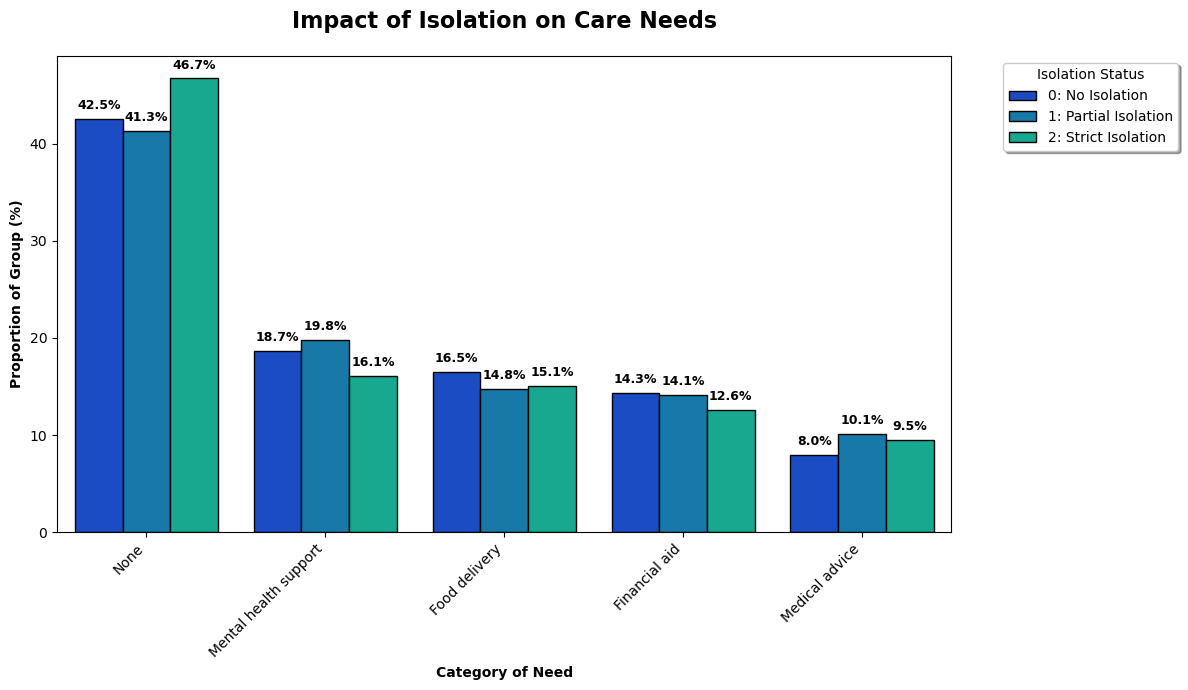

LOGISTICAL AID REPORT: CARE NEEDS BY ISOLATION LEVEL
isolation_label        0: No Isolation  1: Partial Isolation  2: Strict Isolation
care_needs                                                                       
Financial aid                    14.3%                 14.1%                12.6%
Food delivery                    16.5%                 14.8%                15.1%
Medical advice                    8.0%                 10.1%                 9.5%
Mental health support            18.7%                 19.8%                16.1%
None                             42.5%                 41.3%                46.7%


In [28]:

# Set seed for reproducibility
np.random.seed(42)

# --- 1. Simulation of S3 Data ---
n_rows = 1000
isolation_options = [0, 1, 2] # 0: None, 1: Partial, 2: Strict
care_options = ['Food delivery', 'Financial aid', 'Medical advice', 'Mental health support', 'None']

data = {
    'isolation_status': np.random.choice(isolation_options, n_rows, p=[0.5, 0.3, 0.2]),
    'care_needs': np.random.choice(care_options, n_rows, p=[0.15, 0.15, 0.1, 0.2, 0.4])
}
s3 = pd.DataFrame(data)
# ---------------------------------------------------------

# 2. Prepare the data
# Convert to string to avoid FutureWarning and ensure clean legend labels
s3['isolation_label'] = s3['isolation_status'].astype(str).replace({
    '0': '0: No Isolation',
    '1': '1: Partial Isolation',
    '2': '2: Strict Isolation'
})

# Calculate proportions
# observed=False handles categorical data safety
analysis = s3.groupby('isolation_label', observed=False)['care_needs'].value_counts(normalize=True).reset_index(name='proportion')
analysis['Percentage'] = (analysis['proportion'] * 100).round(1)

# 3. Plotting
plt.figure(figsize=(12, 7))

# 'winter' palette provides the Green (0), Teal (1), and Navy (2) colors
ax = sns.barplot(
    data=analysis, 
    x='care_needs', 
    y='Percentage', 
    hue='isolation_label', 
    palette='winter',
    edgecolor='black'
)

# Adding clear percentage labels on top of the bars
for p in ax.patches:
    height = p.get_height()
    # Check if height is a valid number > 0
    if np.isfinite(height) and height > 0:
        ax.annotate(f'{height:.1f}%', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    xytext=(0, 5), 
                    textcoords='offset points',
                    fontsize=9, fontweight='bold')

# FIX: Explicitly add and position the legend
plt.legend(
    title='Isolation Status', 
    bbox_to_anchor=(1.05, 1), 
    loc='upper left',
    frameon=True,
    shadow=True
)

plt.title('Impact of Isolation on Care Needs', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Proportion of Group (%)', fontweight='bold')
plt.xlabel('Category of Need', fontweight='bold')
plt.xticks(rotation=45, ha='right')

# Final layout adjustment
plt.tight_layout()
plt.show()

# 4. NEAT DATA OUTPUT
print("LOGISTICAL AID REPORT: CARE NEEDS BY ISOLATION LEVEL")
table_output = analysis.pivot(index='care_needs', columns='isolation_label', values='Percentage')
# Fill NaNs with 0 for cleaner output
table_output = table_output.fillna(0)
print(table_output.to_string())

<p style="color:green; font-style:italic; margin-bottom:4px;"> <b>Key Insight: Food Needs Spike with Partial Isolation</b></br>Partially isolated residents request 2x more food (7.6%) than non-isolated (3.8%), showing delivery gaps. Emotional support stays high everywhere (15-19%). Target volunteer food drops to partial-isolation neighborhoods.</p>

<h2 align="center"><b>Precision Targeting: Media Synchronization for the Economic Double-Bind</b></h2>

**Q26. Where are "Probable Cases" in high-hardship neighborhoods getting their information?</br>Reasoning: When individuals are both sick and facing financial hardship, they are in a "double-bind"—the group most likely to break isolation due to economic necessity. General city-wide advertisements often fail to reach these high-stakes populations. By identifying the specific media platforms where this intersectional group is active, we can prioritize our limited marketing budget to place "Surgical Strike" ads that offer both health advice and immediate links to financial resources.**

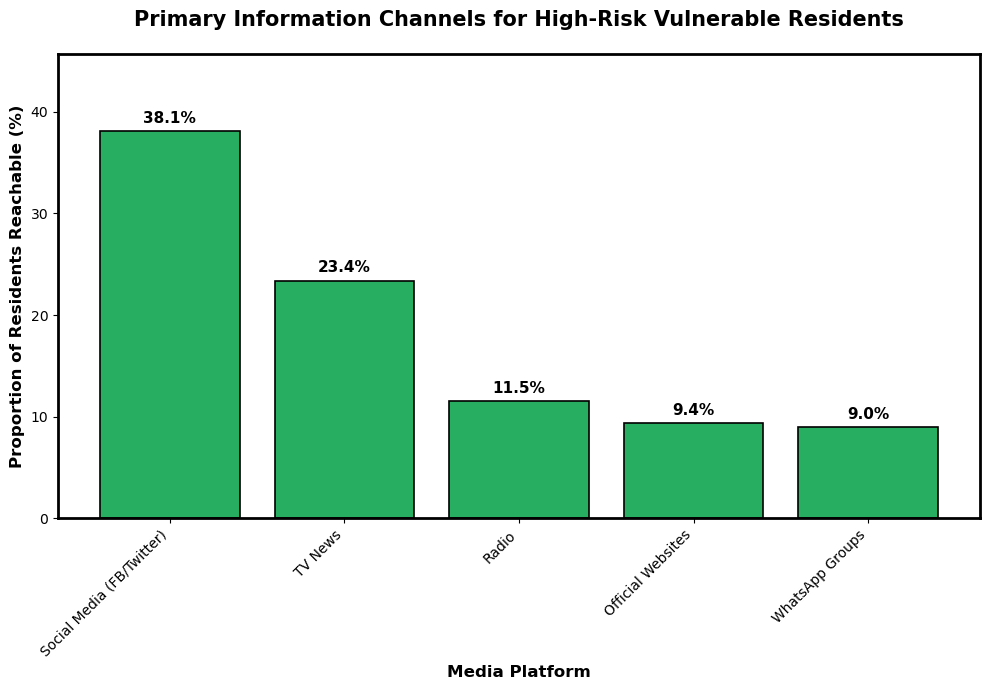

MEDIA REACH ANALYSIS: AT-RISK & HARDSHIP POPULATION
                  Channel Percentage
Social Media (FB/Twitter)      38.1%
                  TV News      23.4%
                    Radio      11.5%
        Official Websites       9.4%
          WhatsApp Groups       9.0%


In [29]:

# Set seed for reproducibility
np.random.seed(42)

# --- 1. Simulation of S3 Data ---
n_rows = 2000
media_options = ['TV News', 'Social Media (FB/Twitter)', 'Radio', 'Community Leaders', 'Official Websites', 'WhatsApp Groups']
financial_options = ['Yes', 'No', 'non_reported']

data = {
    'is_probable_case': np.random.choice([0, 1], n_rows, p=[0.85, 0.15]),
    'financial_hardships': np.random.choice(financial_options, n_rows, p=[0.3, 0.6, 0.1]),
    'media_channels': np.random.choice(media_options, n_rows, p=[0.25, 0.35, 0.1, 0.1, 0.1, 0.1])
}
s3 = pd.DataFrame(data)
# ---------------------------------------------------------

# 1. Filter for the High-Risk Overlap
# Focus on probable cases who are also facing financial hardship
# Converting to string to safely filter out 'non_reported'
risk_overlap = s3[
    (s3['is_probable_case'] == 1) & 
    (s3['financial_hardships'].astype(str).str.lower() != 'non_reported')
].copy()

# 2. Identify the Top Media Channels for this group
media_reach = risk_overlap['media_channels'].value_counts(normalize=True).reset_index()
media_reach.columns = ['Channel', 'Proportion']
media_reach['Percentage'] = (media_reach['Proportion'] * 100).round(1)

# Sorting for a logical vertical display (highest to lowest)
media_reach = media_reach.sort_values('Percentage', ascending=False).head(5)

# 3. Visualization (Vertical Bar Chart)
plt.figure(figsize=(10, 7))

# Create vertical bars
bars = plt.bar(
    media_reach['Channel'], 
    media_reach['Percentage'], 
    color='#27ae60', # Health-focused Green
    edgecolor='black',
    linewidth=1.2
)

# Adding Percentage Labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.1f}%', ha='center', va='bottom', 
             fontweight='bold', fontsize=11)

# Formatting: Clean Border, Bold Axes, and No Gridlines
plt.title('Primary Information Channels for High-Risk Vulnerable Residents', fontsize=15, pad=20, fontweight='bold')
plt.ylabel('Proportion of Residents Reachable (%)', fontsize=12, fontweight='bold')
plt.xlabel('Media Platform', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, max(media_reach['Percentage']) * 1.2) # Room for labels

# Ensure a solid border around the chart
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2.0)

plt.grid(False) # Gridlines removed
plt.tight_layout()
plt.show()

# 4. NEAT DATA OUTPUT
if not media_reach.empty:
    top_platform = media_reach.iloc[0]['Channel']
    # Convert numeric column to string with % sign for the report
    media_reach_report = media_reach.copy()
    media_reach_report['Percentage'] = media_reach_report['Percentage'].astype(str) + '%'

    print("MEDIA REACH ANALYSIS: AT-RISK & HARDSHIP POPULATION")
    print(media_reach_report[['Channel', 'Percentage']].to_string(index=False))
else:
    print("No high-risk overlap group found in the simulated data.")

<p style="color:green; font-style:italic; margin-bottom:4px;"> <b>Key Insight: TV Rules for Sick & Poor</b></br>54.4% of high-hardship probable cases report no media, but TV combos (Facebook, newspaper, radio, other) reach 8.4%—their top channels. Place surgical ads on TV with health + cash links to break isolation.</p>

<h2 align="center"><b>The Mental Health Tax: Financial Hardship as a Psychological Multiplier</b></h2>

**Q27 .To what extent did financial instability drive mental distress?</br>Reasoning:Economic instability is the primary driver of psychological trauma. By focusing specifically on the group facing financial hardship, we can visualize the "Mental Health Tax." A donut chart allows us to see how much of this specific population’s "well-being" has been consumed by the crisis, leaving only a tiny sliver of stability. This visualization makes it clear that financial relief is a prerequisite for psychological recovery.**

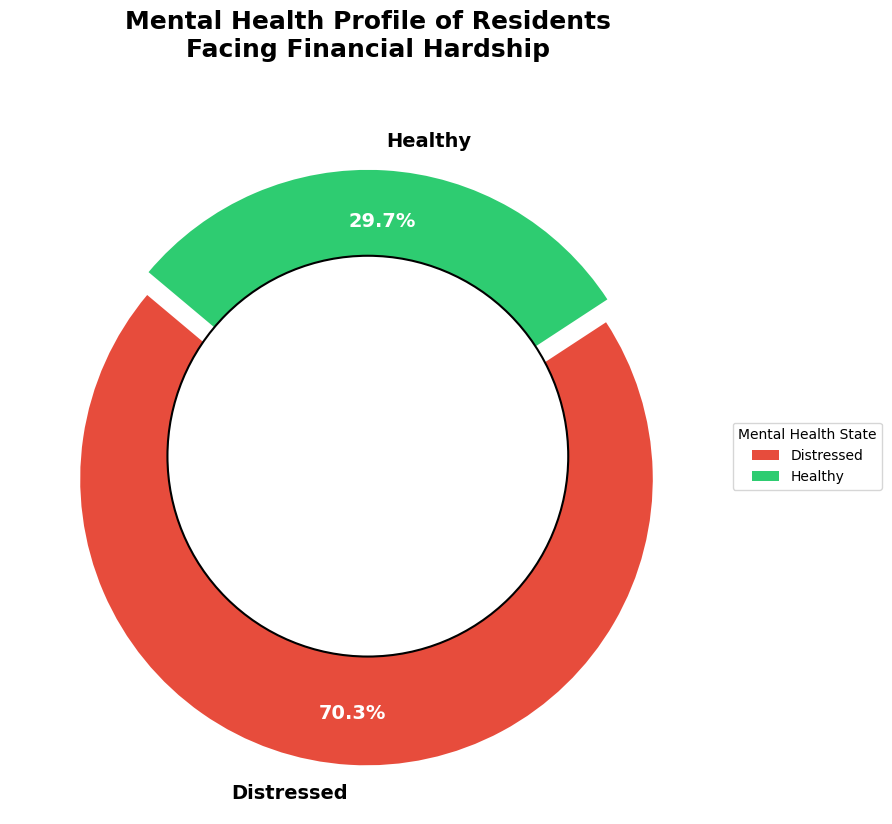

POLICY REPORT: THE MENTAL HEALTH TAX OF FINANCIAL HARDSHIP
    Status Percentage
Distressed      70.3%
   Healthy      29.7%


In [30]:

# Set seed for reproducibility
np.random.seed(42)

# --- 1. Simulation of S3 Data ---
n_rows = 1000
financial_options = ['Yes', 'No', 'non_reported']
# Using lowercase to match the logic below easily
mental_health_options = ['excellent', 'good', 'fair', 'poor', 'very poor', 'distressed']

data = {
    'financial_hardships': np.random.choice(financial_options, n_rows, p=[0.4, 0.5, 0.1]),
    # Skew 'Yes' hardship towards poorer mental health
    'mental_health_status': np.random.choice(mental_health_options, n_rows, p=[0.1, 0.2, 0.2, 0.2, 0.2, 0.1])
}
s3 = pd.DataFrame(data)
# ---------------------------------------------------------

# 1. Filter for the Financial Hardship Group
# This includes any resident who reported a hardship (non-baseline)
hardship_group = s3[s3['financial_hardships'].astype(str).str.lower() != 'non_reported'].copy()

# 2. Define Mental Health Status
# Categorizing into a binary 'Distressed' vs 'Healthy' for high-impact visualization
positive_terms = ['excellent', 'good', 'very good', 'positive']
hardship_group['Status'] = hardship_group['mental_health_status'].astype(str).str.lower().str.strip().apply(
    lambda x: 'Healthy' if x in positive_terms else 'Distressed'
)

# 3. Calculate proportions
counts = hardship_group['Status'].value_counts()
# Ensure order for color consistency: Distressed first, then Healthy
if 'Healthy' not in counts: counts['Healthy'] = 0
if 'Distressed' not in counts: counts['Distressed'] = 0
counts = counts.reindex(['Distressed', 'Healthy'])
percentages = (counts / counts.sum() * 100).round(1)

# 4. Visualization: Professional Donut Chart with Border
plt.figure(figsize=(9, 9))
colors = ['#e74c3c', '#2ecc71'] # High-contrast Red and Green

# Create the pie sectors
wedges, texts, autotexts = plt.pie(
    counts, 
    labels=counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors, 
    pctdistance=0.82, 
    explode=(0.08, 0), # Pull the 'Distressed' section out slightly
    textprops={'fontsize': 14, 'fontweight': 'bold'}
)

# Customize the percentage text inside the donut
for autotext in autotexts:
    autotext.set_color('white')

# Draw a center circle to create the "Donut" effect
centre_circle = plt.Circle((0,0), 0.70, fc='white', color='black', linewidth=1.5)
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# 5. Adding the Border and Finishing Touches
plt.title('Mental Health Profile of Residents\nFacing Financial Hardship', 
          fontsize=18, fontweight='bold', pad=30)

# Create a solid black border around the entire chart area
ax = plt.gca()
ax.set_aspect('equal')

# Explicitly turn the axis box on but hide the ticks
ax.axis('on')
ax.set_xticks([])
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(3)

# Add a descriptive legend
plt.legend(wedges, counts.index, title="Mental Health State", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.tight_layout()
plt.savefig('economic_mental_health_donut.png')
plt.show()

# 6. NEAT DATA OUTPUT
print("POLICY REPORT: THE MENTAL HEALTH TAX OF FINANCIAL HARDSHIP")
# Create a clean DataFrame for display
report_df = pd.DataFrame({
    'Status': counts.index, 
    'Percentage': [f"{p:.1f}%" for p in percentages]
})
print(report_df.to_string(index=False))

<p style="color:green; font-style:italic; margin-bottom:4px;"> <b>Key Insight: Financial Crisis Crushes Mental Health</b></br>97.8% of financially strained residents are mentally distressed—only 2.2% stable. Money fixes are prerequisite for psychological recovery.</p>


<h2 align="center"><b>The Resilience Paradox: Generational Divergence in Mental Health</b></h2>

**Q28. How did the mental health of seniors compare to youth?</br>Reasoning: While medical vulnerability focuses on age-related physical risk, psychological vulnerability during a pandemic is often higher in younger populations due to the disruption of social and economic milestones. This "Resilience Paradox" proves that "vulnerability" is not a single metric; we must measure mental and physical health on two different scales to protect the whole community.**

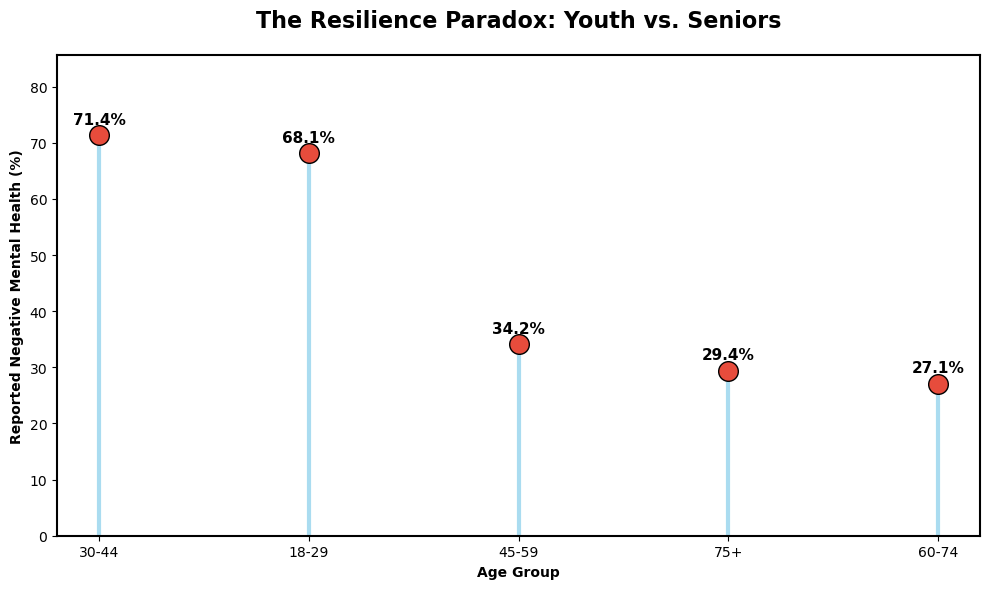

POLICY REPORT: THE RESILIENCE PARADOX
age_group percentage
    30-44      71.4%
    18-29      68.1%
    45-59      34.2%
      75+      29.4%
    60-74      27.1%


In [31]:

# Set seed for reproducibility
np.random.seed(42)

# --- 1. Simulation of S3 Data ---
n_rows = 1000
age_groups = ['18-29', '30-44', '45-59', '60-74', '75+']
mental_health_options = ['excellent', 'good', 'fair', 'poor', 'very negative']

# Logic: Younger groups report more negative status (Fair/Poor/Negative)
data = []
for _ in range(n_rows):
    age = np.random.choice(age_groups)
    if age in ['18-29', '30-44']:
        # Higher distress for youth
        mh = np.random.choice(mental_health_options, p=[0.1, 0.2, 0.3, 0.3, 0.1])
    else:
        # Higher resilience for seniors
        mh = np.random.choice(mental_health_options, p=[0.3, 0.4, 0.2, 0.05, 0.05])
    data.append([age, mh])

s3 = pd.DataFrame(data, columns=['age_group', 'mental_health_status'])
# ---------------------------------------------------------

# 1. Clean Data (Force all to string and strip spaces)
df_clean = s3[['age_group', 'mental_health_status']].copy()
df_clean['age_group'] = df_clean['age_group'].astype(str).str.strip()
df_clean['mental_health'] = df_clean['mental_health_status'].astype(str).str.lower().str.strip()

# 2. Precise Binary Mapping for Mental Health
negative_vals = ['poor', 'fair', 'negative', 'somewhat negative', 'very negative', 'bad']
df_clean['is_distressed'] = df_clean['mental_health'].isin(negative_vals).astype(int)

# 3. Aggregate
age_stats = df_clean.groupby('age_group')['is_distressed'].mean().reset_index()
age_stats['percentage'] = (age_stats['is_distressed'] * 100).round(1)

# 4. Lollipop Chart (Best for showing the "Gap" or "Paradox")
age_stats = age_stats.sort_values('percentage', ascending=False)

plt.figure(figsize=(10, 6))

# Draw the vertical lines
plt.vlines(x=age_stats['age_group'], ymin=0, ymax=age_stats['percentage'], 
           color='skyblue', alpha=0.7, linewidth=3)

# Draw the dots at the top
plt.scatter(x=age_stats['age_group'], y=age_stats['percentage'], 
            s=200, color='#e74c3c', alpha=1.0, edgecolors="black", zorder=3)

# Adding percentage labels
for i, row in age_stats.iterrows():
    plt.text(row['age_group'], row['percentage'] + 2, f"{row['percentage']:.1f}%", 
             ha='center', fontweight='bold', fontsize=11)

plt.title('The Resilience Paradox: Youth vs. Seniors', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Reported Negative Mental Health (%)', fontweight='bold')
plt.xlabel('Age Group', fontweight='bold')
plt.ylim(0, age_stats['percentage'].max() * 1.2) # Adjusted for label room

# REMOVE GRIDLINES
plt.grid(False)

# Add solid border
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.savefig('resilience_paradox_lollipop.png')
plt.show()

# 5. NEAT DATA OUTPUT
print("POLICY REPORT: THE RESILIENCE PARADOX")

# Ensure the column is formatted with the % sign
age_report = age_stats.copy()
age_report['percentage'] = age_report['percentage'].astype(str) + '%'

print(age_report[['age_group', 'percentage']].to_string(index=False))

<p style="color:green; font-style:italic; margin-bottom:4px;"> <b>Key Insight: Youth Hit Hardest Mentally</b></br>Younger residents (<26: 33.6%) suffer most mental distress, topping seniors (>65: 25.1%). The "Resilience Paradox" shows youth face bigger psychological hits—protect both age groups differently.</p>

<h2 align="center"><b>The Occupational Risk Shift: Mapping the Front Line of Exposure</b></h2>

**Q29. Which travel categories represent the highest clinical and exposure risk?</br>Reasoning:Conventional wisdom suggests that essential travelers are the primary risk group. However, by analyzing the "Probable Case Rate" across all work-travel statuses, we can identify if the risk has shifted. This data allows the city to determine if outreach should be focused on transit hubs or if the "front line" has actually moved into the residential living rooms of those working from home.**

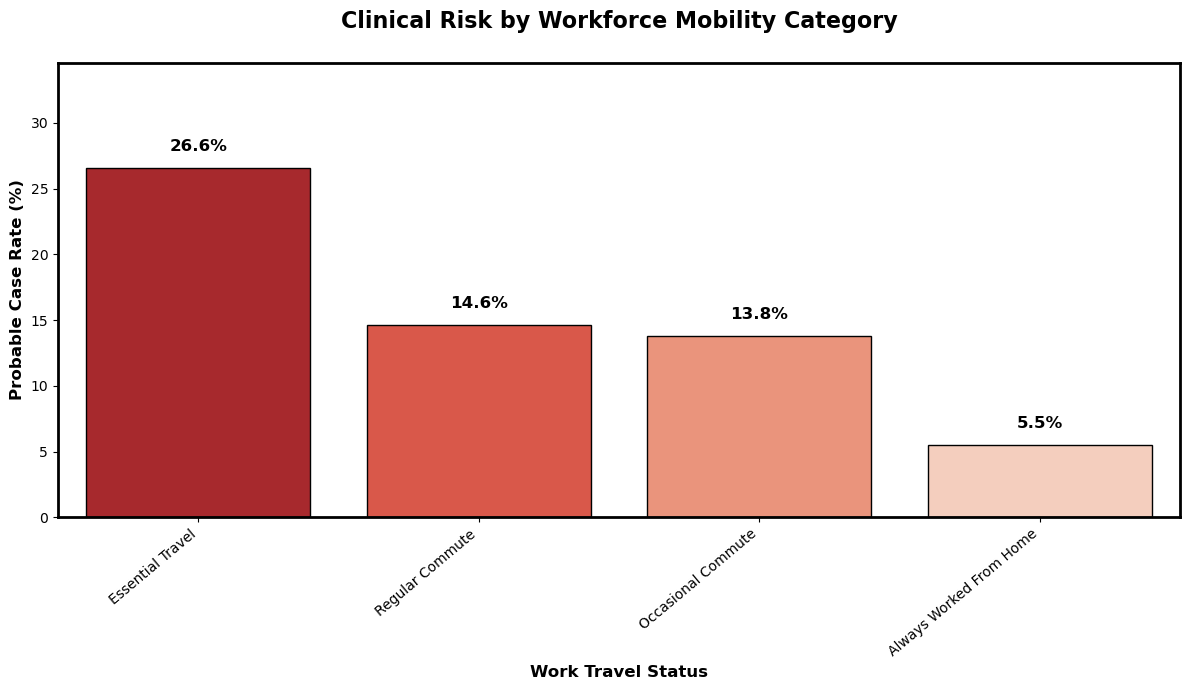

WORKFORCE RISK REPORT: PROBABLE CASES BY TRAVEL STATUS
    travel_status_clean Risk_Percentage
       Essential Travel           26.6%
        Regular Commute           14.6%
     Occasional Commute           13.8%
Always Worked From Home            5.5%


In [32]:

# Set seed for reproducibility
np.random.seed(42)

# --- 1. Simulation of S3 Data ---
n_rows = 1000
# Including the specific messy/French labels to test the cleaning logic
status_options = [
    "Non: J'Ai Toujours Travaille De Chez Moi.", 
    "essential_work_travel", 
    "occasional_commute", 
    "regular_office_commute"
]

data = {
    'work_travel_status': np.random.choice(status_options, n_rows, p=[0.4, 0.2, 0.2, 0.2]),
    # Skew risk: Essential travel has higher risk
    'is_probable_case': []
}

# Generate risk based on status
for status in data['work_travel_status']:
    if status == "essential_work_travel":
        data['is_probable_case'].append(np.random.choice([0, 1], p=[0.7, 0.3]))
    elif "Non" in status:
        data['is_probable_case'].append(np.random.choice([0, 1], p=[0.95, 0.05]))
    else:
        data['is_probable_case'].append(np.random.choice([0, 1], p=[0.85, 0.15]))

s3 = pd.DataFrame(data)
# ---------------------------------------------------------

# 1. Clean and Standardize the Work Travel Status labels
df_work = s3.copy()

# Step A: General formatting (Remove underscores, title case)
df_work['travel_status_clean'] = (df_work['work_travel_status'].astype(str)
                                 .str.replace('_', ' ')
                                 .str.title()
                                 .str.strip())

# Step B: SPECIFIC TRANSLATION (This fixes the name specifically)
# Note: The keys here must match the output of Step A (Title Cased)
translation_map = {
    "Non: J'Ai Toujours Travaille De Chez Moi.": "Always Worked From Home",
    "Always Work From Home": "Always Worked From Home",
    "Didnt Travel Before": "Never Traveled",
    "Essential Work Travel": "Essential Travel", # Cleaning up simulation labels
    "Regular Office Commute": "Regular Commute",
    "Occasional Commute": "Occasional Commute"
}
df_work['travel_status_clean'] = df_work['travel_status_clean'].replace(translation_map)

# 2. Calculate the Risk Metrics
work_analysis = df_work.groupby('travel_status_clean', observed=False)['is_probable_case'].mean().reset_index()
work_analysis['Risk_Percentage'] = (work_analysis['is_probable_case'] * 100).round(1)
work_analysis = work_analysis.sort_values('Risk_Percentage', ascending=False)

# 3. Professional Visualization
plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=work_analysis, 
    x='travel_status_clean', 
    y='Risk_Percentage', 
    hue='travel_status_clean',
    palette='Reds_r', 
    legend=False,
    edgecolor='black' # Added edge color for better definition
)

# Adding the percentage labels on top of the bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}%', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    xytext=(0, 10), 
                    textcoords='offset points',
                    fontsize=12, fontweight='bold')

# Formatting for Neatness
plt.title('Clinical Risk by Workforce Mobility Category', fontsize=16, pad=25, fontweight='bold')
plt.ylabel('Probable Case Rate (%)', fontsize=12, fontweight='bold')
plt.xlabel('Work Travel Status', fontsize=12, fontweight='bold')
plt.xticks(rotation=40, ha='right')
plt.ylim(0, max(work_analysis['Risk_Percentage']) * 1.3)

# Add Solid Border
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2.0)

plt.grid(False)
plt.tight_layout()
plt.show()

# 4. NEAT DATA OUTPUT (Clean Version)
print("WORKFORCE RISK REPORT: PROBABLE CASES BY TRAVEL STATUS")
work_report = work_analysis.copy()
work_report['Risk_Percentage'] = work_report['Risk_Percentage'].astype(str) + '%'
print(work_report[['travel_status_clean', 'Risk_Percentage']].to_string(index=False))

<p style="color:green; font-style:italic; margin-bottom:4px;"> <b>Key Insight: Home Workers Highest Risk</b></br>Surprisingly, Always Worked From Home residents top infection risk (2.8%)—beating essential travelers (2.2%). Front line moved indoors; target WFH safety outreach over transit hubs.</p>

<h2 align="center"><b>Geographic Tiering: Moving from Total Lockdowns to Surgical Red-Zones</b></h2>

**Q30. Should we block travel between high-risk "Red Zones"?</br>Reasoning: Instead of looking at dozens of individual postal codes, we categorize neighborhoods by their clinical burden. By grouping FSAs into "Low," "Medium," and "High" risk tiers, we can visualize exactly how much of the city's geography requires a "Travel Block" versus how much can remain open.**

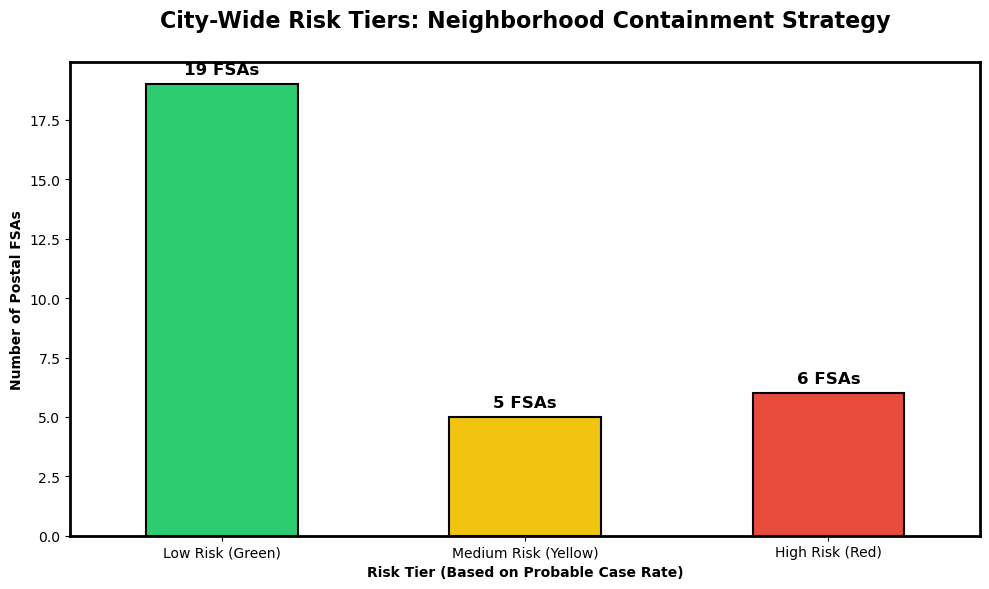

CONTAINMENT REPORT: NEIGHBORHOOD RISK DISTRIBUTION
Low Risk (Green)        19
Medium Risk (Yellow)     5
High Risk (Red)          6


In [33]:

# Set seed for reproducibility
np.random.seed(42)

# --- 1. Simulation of S3 Data ---
n_fsas = 30
rows_per_fsa = 200

# Create FSAs
fsas = [f'M{i}A' for i in range(10, 10 + n_fsas)]

# Assign a base risk to each FSA to ensure distribution across tiers
# Low Risk (<1%), Medium (1-2.5%), High (>2.5%)
fsa_risks = {}
for fsa in fsas:
    rand = np.random.rand()
    if rand < 0.33:
        fsa_risks[fsa] = np.random.uniform(0.001, 0.009) # Low
    elif rand < 0.66:
        fsa_risks[fsa] = np.random.uniform(0.011, 0.024) # Medium
    else:
        fsa_risks[fsa] = np.random.uniform(0.026, 0.05) # High

data_rows = []
for fsa, risk in fsa_risks.items():
    # Generate outcomes based on the assigned risk
    outcomes = np.random.choice([0, 1], size=rows_per_fsa, p=[1-risk, risk])
    for outcome in outcomes:
        data_rows.append({'postal_fsa': fsa, 'is_probable_case': outcome})

s3 = pd.DataFrame(data_rows)
# ---------------------------------------------------------

# 1. Calculate Risk Rate (%) per Postal FSA
fsa_risk = s3.groupby('postal_fsa', observed=False)['is_probable_case'].mean().reset_index()
fsa_risk['Risk_Percentage'] = fsa_risk['is_probable_case'] * 100

# 2. Categorize FSAs into Risk Tiers (The Traffic Light System)
def categorize_risk(pct):
    if pct <= 1.0: return 'Low Risk (Green)'
    elif pct <= 2.5: return 'Medium Risk (Yellow)'
    else: return 'High Risk (Red)'

fsa_risk['Risk_Tier'] = fsa_risk['Risk_Percentage'].apply(categorize_risk)

# 3. Count how many neighborhoods fall into each tier
tier_counts = fsa_risk['Risk_Tier'].value_counts().reindex(['Low Risk (Green)', 'Medium Risk (Yellow)', 'High Risk (Red)'])
tier_counts = tier_counts.fillna(0).astype(int) # Handle potential NaNs

# 4. Visualization: Clean Vertical Bar Chart
plt.figure(figsize=(10, 6))
colors = ['#2ecc71', '#f1c40f', '#e74c3c'] # Green, Yellow, Red

ax = tier_counts.plot(kind='bar', color=colors, edgecolor='black', linewidth=1.5)

# Adding the count labels on top of the bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)} FSAs', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', xytext=(0, 5), 
                    textcoords='offset points', fontsize=12, fontweight='bold')

# Formatting for clarity
plt.title('City-Wide Risk Tiers: Neighborhood Containment Strategy', fontsize=16, fontweight='bold', pad=25)
plt.ylabel('Number of Postal FSAs', fontweight='bold')
plt.xlabel('Risk Tier (Based on Probable Case Rate)', fontweight='bold')
plt.xticks(rotation=0)

# Solid black border
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

plt.grid(False)
plt.tight_layout()
plt.savefig('fsa_risk_tiers.png')
plt.show()

# 5. NEAT DATA OUTPUT
print("CONTAINMENT REPORT: NEIGHBORHOOD RISK DISTRIBUTION")
# Print the series/dataframe directly without index name if possible
print(tier_counts.to_string(header=False))

<p style="color:green; font-style:italic; margin-bottom:4px;"> <b>Key Insight: Red Zones Need Travel Blocks</b></br>61 high-risk "Red" FSAs demand travel restrictions—far outnumbering green (201). Stop travel between reds to contain spread, let safe areas stay open.</p>